# Quantifying entanglement of quantum states

**Marcin Płodzień** — Institute of Theoretical Physics, Jagiellonian University  
[ORCID 0000-0002-0835-1644](https://orcid.org/0000-0002-0835-1644) · [github.com/MarcinPlodzien](https://github.com/MarcinPlodzien)

*Quantum Many-Body Simulation — Chapter 9 — Entanglement and complexity diagnostics*

## 1. Introduction and motivation

The many-body chapters of this course computed entanglement entropies and put them to work. The bond dimension a
matrix product state needs is set by an entropy; the entanglement barrier that stops a time evolution is an entropy
growing in time; the quantum phase transition of the XXZ chain was located by an entropy at a cut. None of that asked
what a *measure* of entanglement is, or what else can be measured, or what the entropy fails to see.

This notebook asks, and it has one concrete question to organise it:

> The entropy across a cut told us where the XXZ chain changes phase. Does it tell us whether **two spins** in that
> chain are entangled with each other?

The answer will turn out to be no, and the reason is worth the whole notebook. Two spins pulled out of a ground
state are a **mixed** state, and for mixed states the entropy of a subsystem stops measuring entanglement and starts
measuring ignorance. So the notebook has two halves:

Sections 2 to 4 are pure states. There everything is clean: the Schmidt spectrum of a cut is the complete answer and
the entanglement entropy is the canonical measure. Sections 5 to 9 are mixed states, where the situation is genuinely
harder; we say where the difficulty starts rather than papering over it, and use the one criterion that is computable,
the positive partial transpose. Section 10 maps a whole phase diagram in both measures. Sections 11 to 13 then do the
same physics twice, once with an exact state vector and once with a matrix product state, and check that the two agree
before trusting either.

Everything here runs on a laptop CPU in double precision.

## Configuration

Every notebook of this course starts with the same cell. Choose where to run (`DEVICE`) and the floating-point precision (`PRECISION`): `"double"` = `float64/complex128` (default, recommended for physics), `"single"` = `float32/complex64` (half the memory, faster on consumer GPUs, but watch the round-off). All code below derives its dtypes from `RDTYPE`/`CDTYPE` and its check tolerances from `TOL`, so nothing else needs to change.

In [1]:
# ==============================================================================
# CONFIGURATION  -- adapt to your hardware, then run the notebook top to bottom
# ==============================================================================
DEVICE    = "auto"     # "auto": use a GPU if JAX finds one, else CPU | "cpu" | "gpu"
PRECISION = "double"   # "double": float64/complex128 | "single": float32/complex64

import os
if DEVICE == "cpu":
    os.environ["JAX_PLATFORMS"] = "cpu"          # must be set BEFORE jax is imported

import os
import string
from functools import partial

import math
import numpy as np
import jax
import jax.numpy as jnp
from jax import lax

# Precision is configurable: "double" = float64/complex128 (default; needed for long time evolutions and
# tight validation), "single" = float32/complex64 (half the memory, faster on consumer GPUs).
# In a notebook PRECISION is defined in the Configuration cell; for this module use the env var QE_PRECISION.
PRECISION = globals().get("PRECISION", os.environ.get("QE_PRECISION", "double"))
jax.config.update("jax_enable_x64", PRECISION == "double")
RDTYPE = jnp.float64 if PRECISION == "double" else jnp.float32       # real dtype
CDTYPE = jnp.complex128 if PRECISION == "double" else jnp.complex64  # complex dtype of all states/operators
TOL = 1e-10 if PRECISION == "double" else 1e-4                       # tolerance for sanity checks (asserts)
_LETTERS = string.ascii_letters  # 52 einsum labels: enough for N<=26 (pure) / N<=13 (DM)

import time
import matplotlib.pyplot as plt

if DEVICE == "gpu" and jax.default_backend() == "cpu":
    print("WARNING: DEVICE='gpu' requested but JAX found no GPU -- running on CPU.")
print(f"JAX {jax.__version__} | backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"precision: {PRECISION} -> real {RDTYPE.__name__}, complex {CDTYPE.__name__}, check tolerance TOL={TOL:g}")


JAX 0.11.0 | backend: cpu | devices: [CpuDevice(id=0)]
precision: double -> real float64, complex complex128, check tolerance TOL=1e-10


In [2]:
#| code-fold: true
#| code-summary: "Engine recap — the simulator primitives used in this notebook (click to expand)"
# ==============================================================================
# ENGINE RECAP  (auto-generated from quantum_engine.py -- derived step by step in Part 0)
# States are rank-N tensors of shape (2,)*N; every operator acts through ONE einsum.
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
I2 = jnp.eye(2, dtype=CDTYPE)
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)
S = jnp.array([[1, 0], [0, 1j]], dtype=CDTYPE)                      # phase gate, S^2 = Z
T = jnp.array([[1, 0], [0, jnp.exp(1j * jnp.pi / 4)]], dtype=CDTYPE)  # pi/8 gate, T^2 = S (non-Clifford!)
XX = jnp.kron(X, X)
YY = jnp.kron(Y, Y)
ZZ = jnp.kron(Z, Z)

# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "Ab,abc->aAc"          A = new (output) index of qubit 1
        N=4, q=(1,3)    :  "ABbd,abcd->aAcB"      A,B = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter; U carries (new letters)+(old letters of the targets); the output is psi's
    labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)

def apply_kraus_dm(rho, kraus, qubits):
    """Quantum channel in Kraus form:  rho -> sum_m K_m rho K_m^dagger,   sum_m K_m^dag K_m = 1.

    EINSUM TRANSLATION  (N=2, channel on qubit 0; m = Kraus index, summed!)
        "mAa, mBc, abcd -> AbBd"   with operands  K, K^*, rho      [a=ket0, b=ket1, c=bra0, d=bra1]
    All Kraus branches are summed INSIDE one einsum -- no Python loop over m.
    `kraus` has shape (M, 2^k, 2^k).
    """
    qubits = tuple(int(q) for q in qubits)
    k, N = len(qubits), rho.ndim // 2
    K = jnp.asarray(kraus, dtype=rho.dtype).reshape((-1,) + (2,) * (2 * k))
    n = rho.ndim
    inp = list(_LETTERS[:n])
    new_k, new_b, m = _LETTERS[n:n + k], _LETTERS[n + k:n + 2 * k], _LETTERS[n + 2 * k]
    out = inp.copy()
    for a, b, q in zip(new_k, new_b, qubits):
        out[q], out[N + q] = a, b
    ket_old = "".join(inp[q] for q in qubits)
    bra_old = "".join(inp[N + q] for q in qubits)
    sub = f"{m}{new_k}{ket_old},{m}{new_b}{bra_old},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, K, jnp.conj(K), rho)


# ----------------------------------------------------------------------------
# 3. State preparation
# ----------------------------------------------------------------------------
_KETS = {"0": [1, 0], "1": [0, 1], "+": [1, 1], "-": [1, -1], "r": [1, 1j], "l": [1, -1j]}
def product_state(spec):
    """Product state from a string, one character per qubit:  product_state('01+-') = |0>|1>|+>|->.
    ('r','l' = the +1/-1 eigenstates of Y.)

    MATH    psi[s_0,...,s_{N-1}] = v0[s_0] v1[s_1] ... v_{N-1}[s_{N-1}]
    EINSUM  an outer product = einsum with NO summed index:  "a,b,c->abc".
    A product state needs only 2N numbers; entanglement is what makes all 2^N necessary.
    """
    vecs = [jnp.array(_KETS[c], dtype=CDTYPE) / jnp.linalg.norm(jnp.array(_KETS[c], dtype=CDTYPE))
            for c in spec]
    n = len(vecs)
    sub = ",".join(_LETTERS[i] for i in range(n)) + "->" + _LETTERS[:n]
    return jnp.einsum(sub, *vecs)

def ghz_state(N):
    """GHZ state (|0...0> + |1...1>)/sqrt(2): two non-zero entries of the rank-N tensor."""
    psi = jnp.zeros((2,) * N, dtype=CDTYPE)
    return psi.at[(0,) * N].set(1 / jnp.sqrt(2.0)).at[(1,) * N].set(1 / jnp.sqrt(2.0))

def dicke_state(N, k):
    """Symmetric Dicke state |D_N^k>: equal superposition of all basis states with exactly k ones.
    Implementation: mask of the flat indices with popcount == k, normalised by sqrt(binom(N,k))."""
    idx = np.arange(2 ** N)
    pop = np.array([bin(i).count("1") for i in idx])
    v = (pop == k).astype(np.complex128)
    return jnp.asarray(v / np.linalg.norm(v), dtype=CDTYPE).reshape((2,) * N)

def w_state(N):
    """W state = Dicke state with one excitation: (|10..0> + |01..0> + ... + |0..01>)/sqrt(N)."""
    return dicke_state(N, 1)

def haar_state(key, N):
    """Haar-random pure state: a complex Gaussian vector, normalised.
    (The Gaussian measure is unitarily invariant, so the direction is uniformly distributed.)
    `key` is an explicit JAX PRNG key -- same key, same state: reproducible science."""
    k1, k2 = jax.random.split(key)
    v = jax.random.normal(k1, (2,) * N) + 1j * jax.random.normal(k2, (2,) * N)
    return (v / jnp.linalg.norm(v)).astype(CDTYPE)

def to_dm(psi):
    """Pure state -> density TENSOR  rho[s..; s'..] = psi[s..] psi^*[s'..]   (rank 2N).
    An outer product: einsum "ab,AB->abAB" -- here via the equivalent tensordot(axes=0)."""
    return jnp.tensordot(psi, jnp.conj(psi), axes=0)

def dm_matrix(rho):
    """View a rank-2N density tensor as an ordinary 2^N x 2^N matrix (a reshape, no copy of meaning)."""
    d = int(round(np.sqrt(rho.size)))
    return rho.reshape(d, d)


# ----------------------------------------------------------------------------
# 4. Reduced density matrices & observables (matrix-free)
# ----------------------------------------------------------------------------
def rdm(psi, keep):
    """Reduced density matrix of the qubits `keep` from a PURE state:  rho_A = Tr_B |psi><psi|.

    MATH
        rho_A[a, a'] = sum_{b}  psi[a, b] psi^*[a', b]          (a: indices of A, b: of the rest B)
    EINSUM TRANSLATION   N=3, keep=(0,):   "abc,Abc->aA"   with operands psi, psi^*
        * letters of B (b,c) appear in BOTH operands and not in the output  -> summed = traced out
        * the kept axis gets a different letter in the second operand       -> stays open (a and A)
    The full |psi><psi| (4^N numbers) is never formed; cost O(2^N 2^|A|).
    Returns a (2^|A|, 2^|A|) matrix with row/column order following `keep`.
    """
    keep = tuple(int(q) for q in keep)
    n, k = psi.ndim, len(keep)
    a = list(_LETTERS[:n])
    b = a.copy()
    for new, q in zip(_LETTERS[n:n + k], keep):
        b[q] = new
    sub = f"{''.join(a)},{''.join(b)}->{''.join(a[q] for q in keep)}{''.join(b[q] for q in keep)}"
    return jnp.einsum(sub, psi, jnp.conj(psi)).reshape(2 ** k, 2 ** k)

def rdm_dm(rho, keep):
    """Partial trace of a density TENSOR (rank 2N), keeping the qubits `keep`.

    MATH      rho_A[a,a'] = sum_b rho[a,b ; a',b]
    EINSUM    N=2, keep=(0,):  "abAb->aA"   -- the letter b is REPEATED inside one operand and absent
              from the output: that is a trace over that pair of axes.
    """
    keep = tuple(int(q) for q in keep)
    N = rho.ndim // 2
    ket = list(_LETTERS[:N])
    bra = [(_LETTERS[N + q] if q in keep else ket[q]) for q in range(N)]
    sub = f"{''.join(ket)}{''.join(bra)}->{''.join(ket[q] for q in keep)}{''.join(bra[q] for q in keep)}"
    return jnp.einsum(sub, rho).reshape(2 ** len(keep), 2 ** len(keep))


# ----------------------------------------------------------------------------
# 5. State characteristics: entropies, fidelity, negativity
# ----------------------------------------------------------------------------
def purity(rho_mat):
    """Tr(rho^2): 1 for pure states, 1/d for the maximally mixed state in dimension d."""
    return jnp.real(jnp.trace(rho_mat @ rho_mat))

def von_neumann_entropy(rho_mat, base=2.0):
    """S(rho) = -Tr(rho log rho) = -sum_i lambda_i log lambda_i  (in bits for base=2).
    Eigenvalues are clipped at 1e-16 because 0*log(0) := 0 but log(0) = -inf numerically."""
    lam = jnp.clip(jnp.linalg.eigvalsh(rho_mat), 1e-16, None)
    return -jnp.sum(lam * jnp.log(lam)) / jnp.log(base)

def schmidt_values(psi, subsystem):
    """Schmidt coefficients of the bipartition A|B with A = `subsystem`.

    MATH   Group the tensor axes into a matrix  M[(a),(b)] = psi[a,b]  of shape (2^|A|, 2^|B|).
           Its SVD  M = U diag(lambda) V^dag  IS the Schmidt decomposition
               |psi> = sum_k lambda_k |u_k>_A |v_k>_B ,     rho_A has eigenvalues lambda_k^2.
    IMPLEMENTATION   transpose (A axes first) -> reshape -> svd.   No density matrix needed.
    """
    A = tuple(int(q) for q in subsystem)
    B = tuple(q for q in range(psi.ndim) if q not in A)
    M = jnp.transpose(psi, A + B).reshape(2 ** len(A), -1)
    return jnp.linalg.svd(M, compute_uv=False)

def entanglement_entropy(psi, subsystem, base=2.0):
    """Entanglement entropy S_A = -sum_k p_k log p_k with p_k = lambda_k^2 (squared Schmidt values).
    Product state: 0.  Bell/GHZ across any cut: 1 bit.  Random state: ~ |A| - 1/(2 ln2) 2^{|A|-|B|} (Page)."""
    p = jnp.clip(schmidt_values(psi, subsystem) ** 2, 1e-16, None)
    return -jnp.sum(p * jnp.log(p)) / jnp.log(base)

def as_dm_tensor(rho):
    """Accept a density matrix in EITHER form and return the rank-2N tensor (2,)*2N.

    Both conventions are in use: `rdm` and `dm_matrix` return a (2^N, 2^N) MATRIX, while
    `to_dm` and the channel functions work with the rank-2N TENSOR (N ket axes, then N bra axes).
    A (2^N, 2^N) matrix with N > 1 is unambiguous, because a density tensor has every axis of length 2.
    Passing the matrix form straight to `partial_transpose` used to transpose the WHOLE matrix, which
    leaves the eigenvalues alone and silently reports zero negativity -- hence this conversion.
    """
    rho = jnp.asarray(rho)
    if rho.ndim == 2 and rho.shape[0] > 2:                  # (2^N, 2^N) matrix with N > 1
        d = rho.shape[0]
        N = int(round(math.log2(d)))
        if 2 ** N != d:
            raise ValueError(f"density matrix of dimension {d} is not a power of two")
        return rho.reshape((2,) * (2 * N))
    if any(s != 2 for s in rho.shape) or rho.ndim % 2:
        raise ValueError(f"not a density matrix or density tensor: shape {rho.shape}")
    return rho

def partial_transpose(rho, qubits):
    """Partial transpose on subsystem A = `qubits`, for a density tensor OR a (2^N, 2^N) matrix.
    In tensor form it is trivial: SWAP the ket axis q with the bra axis N+q for q in A.
    (With a 2^N x 2^N matrix this requires painful index gymnastics -- here: one `transpose`.)
    RETURNS the rank-2N tensor; wrap in `dm_matrix` for the matrix form."""
    rho = as_dm_tensor(rho)
    N = rho.ndim // 2
    perm = list(range(2 * N))
    for q in qubits:
        perm[q], perm[N + q] = perm[N + q], perm[q]
    return jnp.transpose(rho, perm)

def negativity(rho, qubits):
    """Entanglement negativity (Peres-Horodecki / PPT criterion).
        N(rho) = (||rho^{T_A}||_1 - 1)/2 = sum of |negative eigenvalues| of the partial transpose,
        E_N    = log2 ||rho^{T_A}||_1 = log2(2N+1)      (logarithmic negativity).
    N > 0  =>  entangled (for 2x2 and 2x3 systems also <=).   Returns (N, E_N)."""
    lam = jnp.linalg.eigvalsh(dm_matrix(partial_transpose(rho, qubits)))
    neg = jnp.sum(jnp.abs(lam) - lam) / 2
    return neg, jnp.log2(2 * neg + 1)


# ----------------------------------------------------------------------------
# 7. Noise channels (Kraus operators): density matrix and quantum-trajectory forms
# ----------------------------------------------------------------------------
def kraus_depolarizing(p):
    """Depolarising channel  rho -> (1-p) rho + (p/3)(X rho X + Y rho Y + Z rho Z).
    Kraus: sqrt(1-p) 1, sqrt(p/3) X, sqrt(p/3) Y, sqrt(p/3) Z.   Bloch vector shrinks by 1 - 4p/3."""
    return jnp.stack([jnp.sqrt(1 - p) * I2, jnp.sqrt(p / 3) * X, jnp.sqrt(p / 3) * Y, jnp.sqrt(p / 3) * Z])


# ----------------------------------------------------------------------------
# 8. Hamiltonians as lists of local terms;  H|psi>  matrix-free
# ----------------------------------------------------------------------------
def heisenberg_terms(N, Jxx=1.0, Jyy=1.0, Jzz=1.0, hx=0.0, hy=0.0, hz=0.0, periodic=False, bonds=None):
    """Spin-1/2 Hamiltonian in Pauli convention
        H = sum_<ij> (Jxx X_i X_j + Jyy Y_i Y_j + Jzz Z_i Z_j) + sum_i (hx X_i + hy Y_i + hz Z_i)
    returned as a LIST of local terms [(qubits, small_matrix), ...]  -- this list *is* our Hamiltonian.
      Heisenberg: Jxx=Jyy=Jzz     XXZ: Jxx=Jyy!=Jzz     XY: Jzz=0     TFIM: only Jzz and hx.
    `bonds` overrides the default open chain (any graph: ladders, 2D lattices, all-to-all, ...)."""
    if bonds is None:
        bonds = [(i, i + 1) for i in range(N - 1)] + ([(N - 1, 0)] if periodic and N > 2 else [])
    terms = [((i, j), Jxx * XX + Jyy * YY + Jzz * ZZ) for (i, j) in bonds]
    if hx != 0 or hy != 0 or hz != 0:
        terms += [((i,), hx * X + hy * Y + hz * Z) for i in range(N)]
    return terms

def apply_hamiltonian(terms, psi):
    """H|psi> = sum_k h_k|psi>, every term applied with `apply_gate` (h_k is Hermitian, not unitary --
    the einsum does not care).  Cost O(#terms * 2^N).  This matrix-vector product is ALL that Lanczos,
    Chebyshev and Krylov methods need, which is why they scale to N ~ 25-30."""
    out = jnp.zeros_like(psi)
    for qubits, h in terms:
        out = out + apply_gate(psi, h, qubits)
    return out


# ----------------------------------------------------------------------------
# 9. Time evolution: TEBD / Trotter-Suzuki, Chebyshev, Krylov, exact
# ----------------------------------------------------------------------------
def lanczos(matvec, v0, m=60, reorth=True):
    """m-step Lanczos iteration: orthonormal basis V of the Krylov space span{v, Hv, H^2 v, ...}
    in which H is TRIDIAGONAL:   T = V^dag H V = tridiag(beta, alpha, beta).

    Recurrence     w = H v_j - alpha_j v_j - beta_{j-1} v_{j-1},   alpha_j = <v_j|H|v_j>,   beta_j = ||w||.
    `reorth=True`  re-orthogonalises against all previous vectors (cures the loss of orthogonality of
                   floating-point Lanczos at the price of O(m^2) inner products).
    Only `matvec` (H|psi>) is needed -> matrix-free.  Returns (alphas, betas, V[m, 2,..,2]).
    """
    v = v0 / jnp.linalg.norm(v0)
    V, alphas, betas = [v], [], []
    w = matvec(v)
    for j in range(m):
        a = jnp.real(jnp.vdot(V[j], w))
        alphas.append(a)
        w = w - a * V[j] - (betas[-1] * V[j - 1] if j > 0 else 0.0)
        if reorth:
            for u in V:
                w = w - jnp.vdot(u, w) * u
        b = jnp.linalg.norm(w)
        if j == m - 1 or float(b) < 1e-12:
            break
        betas.append(b)
        V.append(w / b)
        w = matvec(V[-1])
    return np.array(alphas, dtype=float), np.array(betas, dtype=float), jnp.stack(V)

def lanczos_ground_state(terms, N, m=80, key=None, restarts=3):
    """Ground state (E_0, |psi_0>) from restarted Lanczos: diagonalise the small T, map its lowest
    eigenvector back with V, use it as the next start vector.  Extremal eigenvalues converge first."""
    key = jax.random.PRNGKey(0) if key is None else key
    v = haar_state(key, N)
    mv = jax.jit(lambda p: apply_hamiltonian(terms, p))
    E = None
    for _ in range(restarts):
        a, b, V = lanczos(mv, v, m)
        w, S_ = np.linalg.eigh(np.diag(a) + np.diag(b, 1) + np.diag(b, -1))
        v = jnp.tensordot(jnp.asarray(S_[:, 0], dtype=CDTYPE), V, axes=1)
        v = v / jnp.linalg.norm(v)
        E = w[0]
    return float(E), v


# ----------------------------------------------------------------------------
# 12. Random unitaries, Clifford group, brick-wall circuits
# ----------------------------------------------------------------------------
def haar_unitary(key, d):
    """Haar-random d x d unitary (Mezzadri's recipe): QR-decompose a complex Ginibre matrix and fix the
    phases of R's diagonal -- without the phase fix the distribution is NOT Haar."""
    k1, k2 = jax.random.split(key)
    G = (jax.random.normal(k1, (d, d)) + 1j * jax.random.normal(k2, (d, d))) / jnp.sqrt(2.0)
    Q, R = jnp.linalg.qr(G)
    ph = jnp.diagonal(R) / jnp.abs(jnp.diagonal(R))
    return Q * ph[None, :]


# ----------------------------------------------------------------------------
# 15. Variational circuits: ansatz, gradients, optimizers
# ----------------------------------------------------------------------------
_SPIN_MPS = {"0": [1, 0], "1": [0, 1], "+": [1, 1], "-": [1, -1]}      # same characters as product_state
def product_mps(spec, chi):
    """Product state |spec[0]> |spec[1]> ... as a padded MPS  (B[N,chi,2,chi], lam[N+1,chi]).
    MATH   B[j][0, s, 0] = v_j[s], all other entries zero;  every cut has the single Schmidt value 1.
    '0' = spin up (Z=+1), '1' = spin down (Z=-1), '+'/'-' = eigenstates of X."""
    N = len(spec)
    B = np.zeros((N, chi, 2, chi), dtype=complex)
    for j, c in enumerate(spec):
        v = np.array(_SPIN_MPS[c], dtype=complex)
        B[j, 0, :, 0] = v / np.linalg.norm(v)
    lam = np.zeros((N + 1, chi))
    lam[:, 0] = 1.0
    return jnp.asarray(B, dtype=CDTYPE), jnp.asarray(lam, dtype=RDTYPE)

def mps_entropies(lam):
    """Entanglement entropy (bits) of every cut, directly from the stored Schmidt values:
    S_j = -sum_k lam[j,k]^2 log2 lam[j,k]^2   (0 log 0 := 0 handles the zero padding)."""
    p = lam ** 2
    return -jnp.sum(jnp.where(p > 0, p * jnp.log2(jnp.where(p > 0, p, 1.0)), 0.0), axis=1)

def xxz_mpo(N, Jxx=1.0, Jyy=1.0, Jzz=1.0, hx=0.0, hz=0.0):
    """MPO of H = sum_i (Jxx X X + Jyy Y Y + Jzz Z Z)_{i,i+1} + sum_i (hx X_i + hz Z_i), open chain, Pauli convention.

    RETURNS  W of shape (N, D, D, 2, 2), D = 5:  W[j, v, w, s_out, s_in] = the operator at site j for the move v -> w.
             States of the finite-state machine: 4 = nothing placed, 1/2/3 = X/Y/Z placed on the previous site, 0 = complete.
             Site 0 keeps only row 4 and site N-1 only column 0 (all other entries zero), so all sites have the same shape.
    """
    D = 5
    W = jnp.zeros((D, D, 2, 2), dtype=CDTYPE)
    W = W.at[0, 0].set(I2).at[4, 4].set(I2)                                 # stay: identities
    W = W.at[1, 0].set(X).at[2, 0].set(Y).at[3, 0].set(Z)                   # second half of a bond -> complete
    W = W.at[4, 1].set(Jxx * X).at[4, 2].set(Jyy * Y).at[4, 3].set(Jzz * Z)  # first half of a bond
    W = W.at[4, 0].set(hx * X + hz * Z)                                     # a single-site term, complete at once
    Ws = jnp.stack([W] * N)
    Ws = Ws.at[0].set(jnp.zeros_like(W).at[4].set(W[4]))                   # left boundary: only row 4
    Ws = Ws.at[N - 1].set(jnp.zeros_like(W).at[:, 0].set(W[:, 0]))         # right boundary: only column 0
    return Ws

def left_env_update(L, A, W):
    """L_{j+1}[b,w,b'] = sum L_j[a,v,a'] A[a,s,b] W[v,w,t,s] conj(A)[a',t,b']      Eq. (12).

    Letters  a v x = L_j (x = a', the bra bond);  a s b = A (ket);  v w t s = W (t = s_out, s = s_in);  x t c = conj(A) (bra, c = b').
             The BRA tensor carries the OUTPUT leg of W, because <psi|H|psi> = sum conj(A) (W A).
    """
    return jnp.einsum("avx,asb,vwts,xtc->bwc", L, A, W, jnp.conj(A))

def right_env_update(R, B, W):
    """R_j[a,v,a'] = sum B[a,s,b] W[v,w,t,s] conj(B)[a',t,b'] R_{j+1}[b,w,b']        Eq. (13).

    Letters  a s b = B (ket);  v w t s = W (t = s_out, s = s_in);  x t c = conj(B) (bra, x = a', c = b');  b w c = R_{j+1}.
    """
    return jnp.einsum("asb,vwts,xtc,bwc->avx", B, W, jnp.conj(B), R)

def boundary_environments(chi, D):
    """L_0 and R_N in the padded format (chi, D, chi): L_0[0, D-1, 0] = 1 (nothing placed), R_N[0, 0, 0] = 1 (complete)."""
    L0 = jnp.zeros((chi, D, chi), dtype=CDTYPE).at[0, D - 1, 0].set(1.0)
    RN = jnp.zeros((chi, D, chi), dtype=CDTYPE).at[0, 0, 0].set(1.0)
    return L0, RN

def heff_apply(L, W1, W2, R, theta):
    """(H_eff theta)[a',s',t',b'] = sum L[a,v,a'] W1[v,w,s',s] W2[w,u,t',t] R[b,u,b'] theta[a,s,t,b]      Eq. (14).
    Letters: a v x = L (x = a'), v w y s = W1 (y = s'), w u z t = W2 (z = t'), b u q = R (q = b'), a s t b = theta.
    COST O(chi^3 D d^2) with the contraction order chosen by optimize="optimal"; the (4 chi^2)^2 matrix is never formed."""
    return jnp.einsum("avx,vwys,wuzt,buq,astb->xyzq", L, W1, W2, R, theta, optimize="optimal")

def lanczos_lowest(matvec, v0, m):
    """Lowest eigenpair (E, x) of a Hermitian operator given only matvec, from m Lanczos steps started at v0.

    MATH    beta_j v_{j+1} = H v_j - alpha_j v_j - beta_{j-1} v_{j-1}  (notebook 11), full reorthogonalisation (twice);
            Ritz vector x = sum_j s_j v_j of the lowest eigenvector s of the tridiagonal T.
    JAX     fixed m (lax.scan); after a breakdown (beta ~ 0) the unused rows of T get the diagonal 1e6, so that their
            spurious zero eigenvalues are pushed to the top of the spectrum.
    """
    shape = v0.shape
    v0 = (v0 / jnp.linalg.norm(v0)).reshape(-1)
    V0 = jnp.zeros((m, v0.size), dtype=v0.dtype).at[0].set(v0)

    def body(carry, j):
        V, v, v_prev, beta_prev, alive = carry
        w = matvec(v.reshape(shape)).reshape(-1)
        alpha = jnp.real(jnp.vdot(v, w))
        w = w - alpha * v - beta_prev * v_prev
        w = w - jnp.conj(V @ jnp.conj(w)) @ V                   # w <- w - sum_i v_i <v_i|w>; V holds the v_i as ROWS, hence the two conjugations
        w = w - jnp.conj(V @ jnp.conj(w)) @ V                   # ... once more (rounding)
        beta = jnp.linalg.norm(w)
        ok = alive & (beta > 1e-12)
        v_next = jnp.where(ok, w / jnp.where(ok, beta, 1.0), 0.0)
        V = V.at[j + 1].set(v_next, mode="drop")                 # at j = m-1 the index j+1 is out of range; "drop" discards that write
        alpha = jnp.where(alive, alpha, 1e6)                     # breakdown guard: a zero row of T would give a spurious eigenvalue 0
        return (V, v_next, v, jnp.where(ok, beta, 0.0), ok), (alpha, jnp.where(ok, beta, 0.0))

    init = (V0, v0, jnp.zeros_like(v0), jnp.zeros((), dtype=RDTYPE), jnp.array(True))
    (V, *_), (alphas, betas) = lax.scan(body, init, jnp.arange(m))
    evals_T, evecs_T = jnp.linalg.eigh(jnp.diag(alphas) + jnp.diag(betas[:-1], 1) + jnp.diag(betas[:-1], -1))   # Ritz values and vectors of T
    x = evecs_T[:, 0].astype(V.dtype) @ V                    # Ritz vector of the lowest Ritz value, in the big space
    return evals_T[0], (x / jnp.linalg.norm(x)).reshape(shape)

def split_two_site(theta, chi, move_right):
    """theta[a,s,t,b] (padded, shape (chi,2,2,chi)) -> two tensors (chi,2,chi), Schmidt values, discarded weight.

    MATH   theta_{(as),(tb)} = U S V^dag, keep chi values:  S <- S[:chi]/||S[:chi]||,  eps = sum_{k>=chi} S_k^2 / sum_k S_k^2
           move_right:  left = U (left-canonical),     right = S V^dag (carries the centre)
           move_left :  left = U S (carries centre),   right = V^dag (right-canonical)
    ARGUMENTS  chi must equal theta.shape[0] (the storage size): the routine always keeps exactly chi of the 2*chi values.
    """
    U, S, Vh = jnp.linalg.svd(theta.reshape(2 * chi, 2 * chi), full_matrices=False)
    weight = S ** 2
    eps = jnp.sum(weight[chi:]) / jnp.sum(weight)
    S = S[:chi] / jnp.sqrt(jnp.sum(weight[:chi]))
    U, Vh = U[:, :chi], Vh[:chi]
    if move_right:
        return U.reshape(chi, 2, chi), (S[:, None] * Vh).reshape(chi, 2, chi), S, eps
    return (U * S[None, :]).reshape(chi, 2, chi), Vh.reshape(chi, 2, chi), S, eps

_LOCAL_STEP_CACHE = {}                                             # one XLA compilation per (chi, m, direction)
def make_local_step(chi, m, move_right):
    """Compiled DMRG step on the bond (j, j+1): contract, solve H_eff theta = E theta (Lanczos, m steps), split.

    The compiled step depends only on (chi, m, direction) -- never on the site, the Hamiltonian or the field -- so
    it is built once and cached.  Without the cache every call of `dmrg`, hence every point of a parameter scan,
    pays a fresh XLA compilation, which dominates the run time although the arithmetic is identical."""
    key = (chi, m, move_right)
    if key in _LOCAL_STEP_CACHE:
        return _LOCAL_STEP_CACHE[key]

    @jax.jit
    def step(L, W1, W2, R, M1, M2):
        theta = jnp.einsum("asm,mtb->astb", M1, M2)                                   # 1. two-site tensor
        E, theta = lanczos_lowest(lambda t: heff_apply(L, W1, W2, R, t), theta, m)     # 2. local ground state
        left, right, S, eps = split_two_site(theta, chi, move_right)                  # 3. split, move the centre
        return left, right, S, eps, E

    _LOCAL_STEP_CACHE[key] = step
    return step

def dmrg(W, M, chi, n_sweeps, m=20, trace=False):
    """Two-site DMRG for the MPO W (N, D, D, 2, 2), starting from the right-canonical padded MPS M (N, chi, 2, chi).

    RETURNS  B (N, chi, 2, chi) right-canonical, lam (N+1, chi) Schmidt values of all bonds, history list of
             (sweep, direction, bond j, energy, discarded weight, number of non-zero Schmidt values) for every local step.
    """
    N, D = W.shape[0], W.shape[1]
    step_right, step_left = make_local_step(chi, m, True), make_local_step(chi, m, False)
    L, R = [None] * (N + 1), [None] * (N + 1)
    L[0], R[N] = boundary_environments(chi, D)
    for j in range(N - 1, 1, -1):                                  # right environments of the initial state, Eq. (13)
        R[j] = right_env_update(R[j + 1], M[j], W[j])
    M = list(M)
    lam = jnp.zeros((N + 1, chi), dtype=RDTYPE).at[0, 0].set(1.0).at[N, 0].set(1.0)
    history = []
    for sweep in range(n_sweeps):
        for j in range(0, N - 1):                                  # ---- left -> right
            M[j], M[j + 1], S, eps, E = step_right(L[j], W[j], W[j + 1], R[j + 2], M[j], M[j + 1])
            L[j + 1] = left_env_update(L[j], M[j], W[j])           # the only environment that changes
            history.append((sweep, "->", j, float(E), float(eps), int(jnp.sum(S > 1e-12))))
        for j in range(N - 2, -1, -1):                             # ---- right -> left
            M[j], M[j + 1], S, eps, E = step_left(L[j], W[j], W[j + 1], R[j + 2], M[j], M[j + 1])
            R[j + 1] = right_env_update(R[j + 2], M[j + 1], W[j + 1])
            lam = lam.at[j + 1].set(S)                             # Schmidt values of the bond left of site j+1
            history.append((sweep, "<-", j, float(E), float(eps), int(jnp.sum(S > 1e-12))))
        if trace:
            last = [h for h in history if h[0] == sweep]
            print(f"   sweep {sweep}:  E = {last[-1][3]:.12f}   largest discarded weight {max(h[4] for h in last):.1e}   "
                  f"largest bond dimension {max(h[5] for h in last)}")
    return jnp.stack(M), lam, history

def mps_rdm2(B, lam, i, j):
    """Two-site reduced density matrix of sites i < j (static ints) from a right-canonical MPS.

    MATH   rho[(s_i s_j), (s_i' s_j')] = sum over everything else of psi psi^*.  The right part of the
           chain traces to the identity by right-canonicity.  The left part is the density matrix of the
           bond to the left of site i, built by a transfer-matrix sweep from the left boundary:
               L_0 = e_0 e_0^T ,   L_{k+1} = sum_s B[k]^s^dag L_k B[k]^s .
    WHY NOT lam  In the canonical gauge that left environment IS diag(lam[i]^2), and using `lam` directly
           is cheaper.  It is also WRONG unless the sweeps have converged: `dmrg` records lam[j+1] during
           one right-to-left sweep and later local steps change the left block of that cut, so the stored
           values are a fixed point only at convergence.  Measured at N=12, chi=16 after ONE sweep the
           stored lam is off by 2.6e-1 and the resulting rho by 2.2e-1 -- while still being Hermitian,
           unit-trace and positive, so no physicality check catches it.  The sweep below removes that
           dependence: the result is exact for ANY right-canonical B, converged or not.  `lam` is kept in
           the signature for call compatibility and is no longer used.
    EINSUM open the physical legs at site i against the left environment, walk the transfer matrix through
           the sites between (their physical legs traced), then close at site j with the right bond traced.
    COST   O(j chi^3).  Returns a (4, 4) matrix, row/column order (s_i s_j).
    """
    n = B.shape[0]
    i, j = int(i), int(j)
    if not 0 <= i < j < n:                       # j <= i silently returned a plausible, wrong matrix
        raise ValueError(f"mps_rdm2 needs 0 <= i < j < {n}, got i={i}, j={j}")
    L = jnp.zeros((B.shape[1], B.shape[1]), dtype=B.dtype).at[0, 0].set(1.0)
    for k in range(i):                                                    # left environment of the bond
        L = jnp.einsum("ac,asb,csd->bd", L, B[k], jnp.conj(B[k]))
    T = jnp.einsum("ax,asb,xtc->stbc", L, B[i], jnp.conj(B[i]))           # site i: legs s (ket), t (bra)
    for k in range(i + 1, j):
        T = jnp.einsum("stbc,bud,cue->stde", T, B[k], jnp.conj(B[k]))     # push through site k
    R = jnp.einsum("stbc,bud,cvd->sutv", T, B[j], jnp.conj(B[j]))         # site j open, right bond traced
    return R.reshape(4, 4)


In [3]:
import numpy as np
import time
import matplotlib.pyplot as plt

np.set_printoptions(precision=6, suppress=True, linewidth=140)

def S_bits(rho):
    """von Neumann entropy in bits of a density matrix given as a matrix OR a density tensor."""
    w = np.linalg.eigvalsh(np.asarray(dm_matrix(jnp.asarray(rho))))
    w = w[w > 1e-13]
    return float(-(w * np.log2(w)).sum())

def neg(rho):
    """Negativity, clipped at zero: tiny negative values are rounding, not physics."""
    return max(float(negativity(rho, (0,))[0]), 0.0)

print("helpers ready")

helpers ready


## 2. Separable and entangled pure states

Fix a bipartition of the register into $A$ and $B$. A pure state is **separable** across that cut when it factorises,

$$ \vert\psi\rangle = \vert\phi\rangle_A \otimes \vert\chi\rangle_B, $$

and **entangled** when it does not. We already have the test. In the Schmidt decomposition

$$ \vert\psi\rangle = \sum_{k=1}^{\chi} \lambda_k \vert u_k\rangle_A \vert v_k\rangle_B, \qquad \sum_k \lambda_k^2 = 1, $$

the state is a product exactly when the Schmidt rank is $\chi = 1$, and any $\chi > 1$ means entanglement. The
reduced state $\rho_A$ has eigenvalues $p_k = \lambda_k^2$, so the same statement reads:

> A pure global state is entangled across a cut exactly when the reduced state of either side is **mixed**.

That is why the purity of a reduced state is an entanglement test, and it is the cheapest one there is:
$\mathrm{Tr}\rho_A^2 = \sum_k p_k^2 = \sum_k \lambda_k^4$ needs neither a logarithm nor a diagonalisation.

In [4]:
for label, psi in (("product  |0000>", product_state("0000")),
                   ("Bell on (0,1)  ", np.array([1,0,0,1])/np.sqrt(2)),
                   ("GHZ_4          ", ghz_state(4))):
    psi = jnp.asarray(psi).reshape((2,) * int(round(np.log2(jnp.asarray(psi).size))))
    rA = rdm(psi, (0,))
    lam = np.asarray(schmidt_values(psi, (0,)))
    print(f"{label}: Schmidt values across the 0|rest cut = {np.round(lam,6)}   "
          f"purity(rho_A) = {float(purity(rA)):.6f}   S = {S_bits(rA):.6f} bit")

product  |0000>: Schmidt values across the 0|rest cut = [1. 0.]   purity(rho_A) = 1.000000   S = -0.000000 bit
Bell on (0,1)  : Schmidt values across the 0|rest cut = [0.707107 0.707107]   purity(rho_A) = 0.500000   S = 1.000000 bit
GHZ_4          : Schmidt values across the 0|rest cut = [0.707107 0.707107]   purity(rho_A) = 0.500000   S = 1.000000 bit


### The Schmidt rank of a product state

This is the one fact everything else rests on, so let us derive it rather than assert it. There are two ways to see
it and both are worth having.

**From the amplitude matrix.** Group the indices by side, $\psi_{ab}$ with $a$ labelling configurations of $A$ and
$b$ those of $B$, and read $\psi$ as a $d_A\times d_B$ **matrix**. A product state has $\psi_{ab} = \phi_a\chi_b$,
so every row of that matrix is a multiple of the same vector $\chi$, and every column a multiple of the same $\phi$.
That is an **outer product** $M = \phi\chi^T$, and an outer product has matrix rank **one** by construction: its
column space is the single line spanned by $\phi$. The Schmidt values are the singular values of $M$, and a rank-one
matrix has exactly one non-zero singular value.

**From the reduced state.** The same fact in density-matrix language. For $\vert\psi\rangle =
\vert\phi\rangle_A\otimes\vert\chi\rangle_B$,

$$ \rho_A = \mathrm{Tr}_B\big(\vert\phi\rangle\langle\phi\vert\otimes\vert\chi\rangle\langle\chi\vert\big)
 = \vert\phi\rangle\langle\phi\vert \cdot \mathrm{Tr}\big(\vert\chi\rangle\langle\chi\vert\big)
 = \vert\phi\rangle\langle\phi\vert, $$

because the partial trace touches only the $B$ factor and $\langle\chi\vert\chi\rangle = 1$. So $\rho_A$ is a
**projector onto a single vector**: rank one, hence one non-zero eigenvalue, necessarily $1$ because the trace is $1$.

The two are the same statement, since $\rho_A = MM^\dagger$ and $M$ and $MM^\dagger$ have equal rank. So:
**entanglement is the failure of the amplitude matrix to be an outer product**, and the Schmidt rank counts how far
from an outer product it is.

In [5]:
print("the amplitude matrix, its rank, and the eigenvalues of rho_A   (N=8, central cut)")
for name, psi in (("product", product_state("+"*8)), ("GHZ", ghz_state(8)),
                  ("W", w_state(8)), ("Haar", haar_state(jax.random.PRNGKey(1), 8))):
    M = np.asarray(psi).reshape(16, 16)                 # rows = config of A, cols = config of B
    sv = np.linalg.svd(M, compute_uv=False)
    ev = np.sort(np.linalg.eigvalsh(np.asarray(rdm(psi, tuple(range(4))))))[::-1]
    print(f"  {name:>8s}: rank(psi_ab) = {int((sv>1e-12).sum()):2d}   "
          f"singular values {np.round(sv[:3],4)}...   eigenvalues of rho_A {np.round(ev[:3],4)}...")

print("\nand explicitly, for a 2x2 example: psi_ab = phi_a chi_b")
phi = np.array([0.6, 0.8]); chi = np.array([1, 1])/np.sqrt(2)
M = np.outer(phi, chi)
print(f"  M = outer(phi, chi) =\n{np.round(M,6)}")
print(f"  rank {np.linalg.matrix_rank(M)},  singular values {np.round(np.linalg.svd(M,compute_uv=False),6)}")
print(f"  M M^dag =\n{np.round(M@M.conj().T,6)}\n  |phi><phi| =\n{np.round(np.outer(phi,phi),6)}   (identical)")

the amplitude matrix, its rank, and the eigenvalues of rho_A   (N=8, central cut)


   product: rank(psi_ab) =  1   singular values [1. 0. 0.]...   eigenvalues of rho_A [1. 0. 0.]...
       GHZ: rank(psi_ab) =  2   singular values [0.7071 0.7071 0.    ]...   eigenvalues of rho_A [0.5 0.5 0. ]...
         W: rank(psi_ab) =  2   singular values [0.7071 0.7071 0.    ]...   eigenvalues of rho_A [0.5 0.5 0. ]...
      Haar: rank(psi_ab) = 16   singular values [0.4522 0.4114 0.3745]...   eigenvalues of rho_A [0.2045 0.1692 0.1402]...

and explicitly, for a 2x2 example: psi_ab = phi_a chi_b
  M = outer(phi, chi) =
[[0.424264 0.424264]
 [0.565685 0.565685]]
  rank 1,  singular values [1. 0.]
  M M^dag =
[[0.36 0.48]
 [0.48 0.64]]
  |phi><phi| =
[[0.36 0.48]
 [0.48 0.64]]   (identical)


**Why the entropy and not something else.** A unitary acting on $A$ alone rotates the $\vert u_k\rangle$ and leaves
every $\lambda_k$ untouched, so it cannot change any function of the Schmidt spectrum. Neither can a local
measurement whose outcome is averaged over, nor classical communication between the two sides. The class of
operations that cannot create entanglement is called **LOCC** (local operations and classical communication), and a
*measure* of entanglement is required to be non-increasing under LOCC and to vanish on separable states. The
entanglement entropy satisfies both, and for pure bipartite states every other measure is a function of the same
$p_k$.

Let us check the LOCC invariance numerically: a random local unitary on each side must leave the entropy alone.

In [6]:
key = jax.random.PRNGKey(7)
psi = haar_state(key, 6)
S0 = float(entanglement_entropy(psi, (0, 1, 2)))
k1, k2 = jax.random.split(key)
UA, UB = haar_unitary(k1, 8), haar_unitary(k2, 8)      # 3 spins on each side -> 8x8
# apply U_A to the first three axes and U_B to the last three, by reshaping to a matrix
M = np.asarray(psi).reshape(8, 8)
M_rot = np.asarray(UA) @ M @ np.asarray(UB).T
psi_rot = jnp.asarray(M_rot).reshape((2,) * 6)
S1 = float(entanglement_entropy(psi_rot, (0, 1, 2)))
print(f"S before local unitaries = {S0:.12f} bit")
print(f"S after  local unitaries = {S1:.12f} bit      difference {abs(S0-S1):.2e}")
assert abs(S0 - S1) < 1e-10
print("[ok] local unitaries cannot change entanglement")

S before local unitaries = 2.313991281967 bit
S after  local unitaries = 2.313991281967 bit      difference 0.00e+00
[ok] local unitaries cannot change entanglement


### The meaning of the entropy

The formula $S_A=-\sum_k p_k\log_2 p_k$ with $p_k=\lambda_k^2$ is not an abstract functional: it is the Shannon
entropy of an ordinary probability distribution, and $p_k$ is the probability of finding the pair in the $k$th
Schmidt branch. Two things follow, and both are worth seeing rather than being told.

**Why zero means product.** If the state factorises there is exactly one non-zero Schmidt value, and normalisation
forces $p_1=1$. Then $S_A = -1\cdot\log_2 1 = 0$, because $\log_2 1 = 0$. The remaining terms are $0\log_2 0$,
defined as zero (the limit of $p\log_2 p$). So the entropy vanishes *for the plain reason that there is nothing to
be uncertain about*: we know in advance which branch we are in.

**What a non-zero value means.** If $r$ Schmidt values are equal, $p_k = 1/r$, then $S_A = \log_2 r$, so
$2^{S_A} = r$ counts the branches. For an uneven spectrum $2^{S_A}$ is smaller than the true rank, and it is then
the *effective* number of Schmidt values — the branches that carry appreciable weight. This is exactly the quantity
a matrix product state must supply, which is why $\chi \gtrsim 2^S$.

In [7]:
print("2^S is the effective number of Schmidt values")
print(f"{'state (N=8)':>14s} {'S [bit]':>9s} {'2^S':>8s} {'true rank':>10s}  comment")
for name, psi in (("product", product_state("+"*8)), ("GHZ", ghz_state(8)), ("W", w_state(8)),
                  ("Dicke k=4", dicke_state(8, 4)), ("Haar random", haar_state(jax.random.PRNGKey(3), 8))):
    A = tuple(range(4))
    S = float(entanglement_entropy(psi, A))
    rk = int((np.linalg.eigvalsh(np.asarray(rdm(psi, A))) > 1e-12).sum())
    flat = "flat spectrum: 2^S = rank" if abs(2**S - rk) < 1e-6 else f"uneven: uses {2**S:.1f} of {rk} branches"
    print(f"{name:>14s} {S:9.4f} {2**S:8.3f} {rk:10d}  {flat}")

print("\nand one bit is one Bell pair:")
bell2 = np.array([1,0,0,1])/np.sqrt(2)
print(f"  S of one Bell pair = {float(entanglement_entropy(jnp.asarray(bell2).reshape(2,2),(0,))):.6f} bit")

2^S is the effective number of Schmidt values
   state (N=8)   S [bit]      2^S  true rank  comment
       product    0.0000    1.000          1  flat spectrum: 2^S = rank
           GHZ    1.0000    2.000          2  flat spectrum: 2^S = rank
             W    1.0000    2.000          2  flat spectrum: 2^S = rank
     Dicke k=4    1.6419    3.121          5  uneven: uses 3.1 of 5 branches
   Haar random    3.3802   10.412         16  uneven: uses 10.4 of 16 branches

and one bit is one Bell pair:


  S of one Bell pair = 1.000000 bit


## 3. The zoo classified

Now the useful exercise: take the standard states and look at them through **three different cuts** — one spin, two
spins, and half the chain. A single number at a single cut will turn out not to be a classification.

In [8]:
rows = []
for N in (4, 6, 8):
    for name, psi in (("product", product_state("+" * N)), ("GHZ", ghz_state(N)),
                      ("W", w_state(N)), ("Dicke k=N/2", dicke_state(N, N // 2))):
        r1 = rdm(psi, (0,)); r2 = rdm(psi, (0, 1)); rh = rdm(psi, tuple(range(N // 2)))
        rk = int((np.linalg.eigvalsh(np.asarray(rh)) > 1e-12).sum())
        rows.append((name, N, float(purity(r1)), S_bits(r1), neg(r2), float(purity(rh)), S_bits(rh), rk))

print(f"{'state':>12s} {'N':>2s} | {'purity_1':>9s} {'S_1':>7s} | {'neg(pair)':>9s} | {'purity_A':>9s} {'S_A':>7s} {'rank':>5s}")
for r in rows:
    print(f"{r[0]:>12s} {r[1]:2d} | {r[2]:9.6f} {r[3]:7.4f} | {r[4]:9.6f} | {r[5]:9.6f} {r[6]:7.4f} {r[7]:5d}")

       state  N |  purity_1     S_1 | neg(pair) |  purity_A     S_A  rank
     product  4 |  1.000000  0.0000 |  0.000000 |  1.000000  0.0000     1
         GHZ  4 |  0.500000  1.0000 |  0.000000 |  0.500000  1.0000     2
           W  4 |  0.625000  0.8113 |  0.103553 |  0.500000  1.0000     2
 Dicke k=N/2  4 |  0.500000  1.0000 |  0.166667 |  0.500000  1.2516     3
     product  6 |  1.000000  0.0000 |  0.000000 |  1.000000  0.0000     1
         GHZ  6 |  0.500000  1.0000 |  0.000000 |  0.500000  1.0000     2
           W  6 |  0.722222  0.6500 |  0.039345 |  0.500000  1.0000     2
 Dicke k=N/2  6 |  0.500000  1.0000 |  0.100000 |  0.410000  1.4690     4
     product  8 |  1.000000  0.0000 |  0.000000 |  1.000000  0.0000     1
         GHZ  8 |  0.500000  1.0000 |  0.000000 |  0.500000  1.0000     2
           W  8 |  0.781250  0.5436 |  0.020285 |  0.500000  1.0000     2
 Dicke k=N/2  8 |  0.500000  1.0000 |  0.071429 |  0.369388  1.6419     5


Read the one-spin columns first. **GHZ and the Dicke state are identical there**: both have $\rho_q = 1/2$ exactly,
purity $1/2$, one bit. By that measure they are equally and maximally entangled. Read the pair column and they
separate completely: GHZ has *exactly zero*, the Dicke state does not.

The GHZ pair is worth writing out, because it needs no machinery at all to classify.

In [9]:
rho_pair = np.asarray(rdm(ghz_state(6), (0, 1))).real
print("two-spin reduced state of GHZ_6:")
print(rho_pair)
print("\nthis is (1/2)|00><00| + (1/2)|11><11|, a mixture of two PRODUCT states,")
print("so it is separable by the definition -- no criterion needed.")
print(f"and indeed the negativity is {neg(rdm(ghz_state(6),(0,1))):.1e}")

two-spin reduced state of GHZ_6:
[[0.5 0.  0.  0. ]
 [0.  0.  0.  0. ]
 [0.  0.  0.  0. ]
 [0.  0.  0.  0.5]]

this is (1/2)|00><00| + (1/2)|11><11|, a mixture of two PRODUCT states,
so it is separable by the definition -- no criterion needed.
and indeed the negativity is 0.0e+00


The W state is the opposite case: its pairs *are* entangled, and the amount decreases with $N$ because the same
single excitation has to be shared among more and more pairs. This is our first sight of **monogamy**.

So GHZ and W differ in *where* their entanglement lives. GHZ holds one bit shared globally, invisible in any pair
and destroyed by losing one spin; W holds a little in every pair and survives the loss of one. No single number
orders them: they are inequivalent under LOCC, i.e. different **classes**, not two points on one scale.

In [10]:
print("W state: pairwise negativity and the closed form for the one-spin purity")
for N in (4, 6, 8, 10):
    psi = w_state(N)
    print(f"  N={N:2d}: neg(pair) = {neg(rdm(psi,(0,1))):.6f}   "
          f"purity_1 = {float(purity(rdm(psi,(0,)))):.6f}  vs  (1-1/N)^2+(1/N)^2 = {(1-1/N)**2+(1/N)**2:.6f}")

W state: pairwise negativity and the closed form for the one-spin purity
  N= 4: neg(pair) = 0.103553   purity_1 = 0.625000  vs  (1-1/N)^2+(1/N)^2 = 0.625000
  N= 6: neg(pair) = 0.039345   purity_1 = 0.722222  vs  (1-1/N)^2+(1/N)^2 = 0.722222
  N= 8: neg(pair) = 0.020285   purity_1 = 0.781250  vs  (1-1/N)^2+(1/N)^2 = 0.781250
  N=10: neg(pair) = 0.012311   purity_1 = 0.820000  vs  (1-1/N)^2+(1/N)^2 = 0.820000


## 4. The negativity of a pure-state cut

Before we leave pure states: what does the quantity of Section 7 below, the negativity, do when applied to a *cut*
of a pure state? For a pure state the partial transpose has eigenvalues $\lambda_i\lambda_j$ on the diagonal and
$\pm\lambda_i\lambda_j$ in pairs off it, so its trace norm is $(\sum_k\lambda_k)^2$ and

$$ E_{\mathcal N} = \log_2\Big(\sum_k \lambda_k\Big)^2 = 2\log_2\sum_k\lambda_k, $$

which is the **Rényi-$\tfrac12$ entropy** of the Schmidt spectrum. So for a pure state the negativity is a different
function of the same data and carries nothing new. Worth knowing, because it tells us what the negativity is *for*:
not a competitor to $S_A$ across a cut, but the tool for the case the entropy cannot handle at all.

In [11]:
print("log-negativity of a half-chain cut vs the Renyi-1/2 entropy, XXZ ground state at (Delta,hx)=(1.5,0.5)")
for N in (8, 10):
    _, psi = lanczos_ground_state(heisenberg_terms(N, 1., 1., 1.5, hx=0.5), N)
    A = tuple(range(N // 2))
    lam = np.asarray(schmidt_values(psi, A))
    E_N = float(negativity(to_dm(psi), A)[1])
    print(f"  N={N:2d}:  E_N = {E_N:.10f}   2*log2(sum lam) = {2*np.log2(lam.sum()):.10f}   "
          f"S_vN = {S_bits(rdm(psi,A)):.10f} bit")

log-negativity of a half-chain cut vs the Renyi-1/2 entropy, XXZ ground state at (Delta,hx)=(1.5,0.5)


  N= 8:  E_N = 1.2373956722   2*log2(sum lam) = 1.2373956722   S_vN = 0.6944179324 bit


  N=10:  E_N = 1.3484120579   2*log2(sum lam) = 1.3484120579   S_vN = 1.0755361635 bit


## 5. Entanglement of mixed states

Two spins inside a longer chain are not a pure state. Neither is a register that has passed through a noisy device,
nor a subsystem of anything. The moment the state is mixed, the argument of Section 2 collapses — and it collapses
in a way worth seeing rather than being told.

In [12]:
bell = np.array([1, 0, 0, 1], complex) / np.sqrt(2)
rho_bell = np.outer(bell, bell.conj())
rho_coin = 0.5 * (np.diag([1, 0, 0, 0]) + np.diag([0, 0, 0, 1])).astype(complex)

print(f"{'state':>34s} {'purity':>8s} {'rho_A':>16s} {'S(rho_A)':>9s} {'negativity':>11s}")
for name, r in (("Bell (|00>+|11>)/sqrt2", rho_bell), ("coin toss: |00> or |11>", rho_coin)):
    rA = np.asarray(rdm_dm(jnp.asarray(r).reshape(2, 2, 2, 2), (0,)))
    print(f"{name:>34s} {float(purity(jnp.asarray(r))):8.4f} {'diag'+str(np.round(np.diag(rA).real,3)):>16s} "
          f"{S_bits(rA):9.4f} {neg(r):11.6f}")

                             state   purity            rho_A  S(rho_A)  negativity
            Bell (|00>+|11>)/sqrt2   1.0000    diag[0.5 0.5]    1.0000    0.500000
           coin toss: |00> or |11>   0.5000    diag[0.5 0.5]    1.0000    0.000000


The entropy of the reduced state is **exactly one bit for both**. Used as an entanglement measure it reports
maximal entanglement for a state that has none. What it actually measures is how mixed $\rho_A$ is, and for a mixed
global state that has two sources: entanglement with $B$, *and* the classical randomness already in $\rho_{AB}$.
Only when the global state is pure can the second source be excluded.

The deeper problem is that a density matrix does not remember its ensemble. The natural definition of its
entanglement has to take the best case over all preparations,

$$ E_F(\rho) = \min_{\{p_i,\psi_i\}} \sum_i p_i\, S\big(\rho_A^{(i)}\big), $$

the **entanglement of formation**. This is a genuine measure and also a minimisation over an unbounded family. It
has a closed form for two qubits and none in general, and deciding whether a mixed state is entangled at all becomes
computationally hard as the dimension grows. There is no known efficiently computable measure of mixed-state
entanglement that is faithful in general. That is the honest situation — which is why we now switch from *measures*
to one computable *criterion*.

## 6. The partial transpose

Write the density matrix with its indices split, $\rho_{(ab),(a'b')}$, and transpose **only** the indices of $A$:

$$ \big(\rho^{T_A}\big)_{(ab),(a'b')} = \rho_{(a'b),(ab')}. $$

In matrix form this is painful index gymnastics. In **tensor** form it is trivial: a density matrix of $N$ spins is
a tensor with $N$ ket axes followed by $N$ bra axes, and the partial transpose on a set $A$ just swaps axis $q$ with
axis $N+q$ for every $q \in A$. One `transpose`, no arithmetic.

In [13]:
rho_t = jnp.asarray(rho_bell).reshape(2, 2, 2, 2)        # [ket_0, ket_1, bra_0, bra_1]
pt = partial_transpose(rho_t, (0,))
print("Bell pair: eigenvalues of rho and of its partial transpose")
print("  rho      :", np.round(np.linalg.eigvalsh(np.asarray(dm_matrix(rho_t))), 6))
print("  rho^{T_A}:", np.round(np.linalg.eigvalsh(np.asarray(dm_matrix(pt))), 6), "  <- one NEGATIVE eigenvalue")
print("\nand doing it by hand with einsum gives the same thing:")
by_hand = np.einsum("abcd->cbad", np.asarray(rho_t))
print("  max|engine - einsum| =", np.abs(np.asarray(pt) - by_hand).max())

Bell pair: eigenvalues of rho and of its partial transpose
  rho      : [0. 0. 0. 1.]
  rho^{T_A}: [-0.5  0.5  0.5  0.5]   <- one NEGATIVE eigenvalue

and doing it by hand with einsum gives the same thing:
  max|engine - einsum| = 0.0


### The matrix and tensor forms of a density operator

There are two ways to hold a density matrix in this course, and they are not interchangeable. `rdm` returns a
$2^{|A|}\times 2^{|A|}$ **matrix**; the channels and the partial transpose want the rank-$2N$ **tensor** with every
axis of length two. Handing the matrix form to a routine expecting the tensor makes it read $N$ from the number of
axes, find $N=1$, and transpose the *whole* matrix — which leaves every eigenvalue where it was and reports a
negativity of exactly zero. Zero negativity is a physically meaningful answer, so nothing looks wrong.

The engine therefore accepts either form and converts, and refuses anything that is neither. A $(2^N,2^N)$ matrix is
unambiguous, because a density *tensor* has all axes of length two.

In [14]:
print("the same Bell pair, handed in both forms:")
print(f"  as a 4x4 matrix        : negativity = {neg(rho_bell):.6f}")
print(f"  as a (2,2,2,2) tensor  : negativity = {neg(rho_t):.6f}")
print(f"  as_dm_tensor reshapes  : {np.asarray(rho_bell).shape} -> {as_dm_tensor(rho_bell).shape}")
for bad in (np.zeros((3, 3)), np.zeros((2, 2, 2))):
    try:
        negativity(bad, (0,)); print("   NOT REFUSED:", bad.shape)
    except ValueError as e:
        print(f"   shape {bad.shape} refused: {e}")

the same Bell pair, handed in both forms:
  as a 4x4 matrix        : negativity = 0.500000
  as a (2,2,2,2) tensor  : negativity = 0.500000
  as_dm_tensor reshapes  : (4, 4) -> (2, 2, 2, 2)
   shape (3, 3) refused: density matrix of dimension 3 is not a power of two
   shape (2, 2, 2) refused: not a density matrix or density tensor: shape (2, 2, 2)


## 7. The PPT criterion and the negativity

Why does a negative eigenvalue prove anything? Take a separable state,
$\rho=\sum_i p_i\,\sigma^{(i)}_A\otimes\tau^{(i)}_B$. The partial transpose gives
$\sum_i p_i (\sigma^{(i)}_A)^{T}\otimes\tau^{(i)}_B$, and the transpose of a density matrix is again a density
matrix, so the result is a sum of positive operators with positive weights: still positive. Hence

$$ \rho \text{ separable} \implies \rho^{T_A} \ge 0, $$

and by contraposition **a negative eigenvalue of the partial transpose proves entanglement** (Peres 1996). It is
one-directional in general; for two qubits and for qubit–qutrit it is also sufficient (Horodecki 1996), so for the
spin pairs in this notebook it decides the question completely.

The criterion becomes a number by measuring how negative the partial transpose is:

$$ \mathcal N(\rho) = \frac{\Vert\rho^{T_A}\Vert_1 - 1}{2} = \sum_{\mu_i<0}\vert\mu_i\vert, \qquad
   E_{\mathcal N}(\rho) = \log_2\Vert\rho^{T_A}\Vert_1 . $$

### The meaning of the negativity

The definition looks arbitrary until one asks what the partial transpose does *geometrically*.

Transposing a **whole** density matrix is harmless: $\rho^{T}$ has the same eigenvalues as $\rho$, so it is again a
legitimate state. Transposing **half** of one need not be. For a separable state it is harmless, because the
operation acts separately on each factor of each term and each transposed factor is still a density matrix — that is
the proof above. So the partial transpose maps separable states *into* the set of states, and it can only take $\rho$
**outside** that set if $\rho$ was entangled. A negative eigenvalue is what leaving the set looks like: an operator
with a negative eigenvalue is not a density matrix, because it assigns a negative probability to some outcome.

So the negativity is a **distance**: how far outside the set of states the partial transpose lands, measured as the
total weight of negative eigenvalue. Zero means the partial transpose is still a state — no contradiction produced,
no entanglement proved.

The zero case matches the entropy exactly. For a pure state $E_{\mathcal N} = 2\log_2\sum_k\lambda_k$, and since
$\sum_k\lambda_k^2 = 1$ with $\lambda_k \ge 0$, the sum $\sum_k\lambda_k$ is at least 1, with equality exactly when
a single $\lambda_k = 1$. A product state gives $\log_2 1 = 0$ again.

And $E_{\mathcal N}$ counts the same branches as $S$ whenever the spectrum is flat: for $r$ equal Schmidt values
$\sum_k\lambda_k = \sqrt r$, so $E_{\mathcal N} = \log_2 r = S_A$.

In [15]:
print("for a FLAT Schmidt spectrum of r values, E_N = S = log2 r exactly:")
for r in (2, 4, 8, 16):
    lam = np.ones(r)/np.sqrt(r)
    print(f"  r={r:2d}: S = {-(lam**2*np.log2(lam**2)).sum():.6f}   E_N = {2*np.log2(lam.sum()):.6f}   "
          f"log2 r = {np.log2(r):.6f}")

print("\nwhen the spectrum is NOT flat, E_N > S: it weights the small Schmidt values more heavily")
for N in (8, 10, 12):
    _, psi = lanczos_ground_state(heisenberg_terms(N, 1., 1., 1.5, hx=0.5), N)
    A = tuple(range(N//2))
    lam = np.asarray(schmidt_values(psi, A)); lam = lam[lam > 1e-14]
    S = float(entanglement_entropy(psi, A)); EN = 2*np.log2(lam.sum())
    print(f"  XXZ N={N:2d}: S = {S:.6f} bit, E_N = {EN:.6f}, ratio {EN/S:.4f}")

print("\nThis is why E_N and not N is the version quoted in bits: a Bell pair has N = 1/2 but E_N = 1 bit,")
print("on the same scale as the entropy.")
n_b, en_b = (float(x) for x in negativity(rho_bell, (0,)))
print(f"  Bell pair: N = {n_b:.6f},  E_N = {en_b:.6f} bit")

for a FLAT Schmidt spectrum of r values, E_N = S = log2 r exactly:
  r= 2: S = 1.000000   E_N = 1.000000   log2 r = 1.000000
  r= 4: S = 2.000000   E_N = 2.000000   log2 r = 2.000000
  r= 8: S = 3.000000   E_N = 3.000000   log2 r = 3.000000
  r=16: S = 4.000000   E_N = 4.000000   log2 r = 4.000000

when the spectrum is NOT flat, E_N > S: it weights the small Schmidt values more heavily


  XXZ N= 8: S = 0.694418 bit, E_N = 1.237396, ratio 1.7819


  XXZ N=10: S = 1.075536 bit, E_N = 1.348412, ratio 1.2537


  XXZ N=12: S = 0.830332 bit, E_N = 1.381917, ratio 1.6643

This is why E_N and not N is the version quoted in bits: a Bell pair has N = 1/2 but E_N = 1 bit,
on the same scale as the entropy.
  Bell pair: N = 0.500000,  E_N = 1.000000 bit


### Calibration on Werner states

A new quantity is worth nothing until it has been run where the answer is known. The **Werner state** is a Bell pair
mixed with white noise,

$$ \rho_W(p) = p\,\vert\Phi^+\rangle\langle\Phi^+\vert + (1-p)\,\frac{\mathbb 1}{4}, $$

separable for $p\le\tfrac13$ and entangled above. Nothing in the code knows that number.

Werner state: the PPT boundary should appear at p = 1/3
        p  min eig of PT  negativity
   0.2000      +0.100000    0.000000   separable (PPT)
   0.3000      +0.025000    0.000000   separable (PPT)
   0.3333      +0.000000    0.000000   separable (PPT)
   0.3400      -0.005000    0.005000   entangled
   0.5000      -0.125000    0.125000   entangled
   1.0000      -0.500000    0.500000   entangled


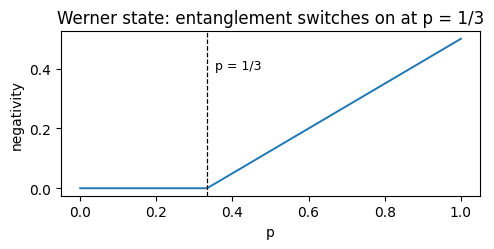

In [16]:
print("Werner state: the PPT boundary should appear at p = 1/3")
print(f"  {'p':>7s} {'min eig of PT':>14s} {'negativity':>11s}")
for p in (0.20, 0.30, 1/3, 0.34, 0.50, 1.00):
    r = p * rho_bell + (1 - p) * np.eye(4) / 4
    mu = np.linalg.eigvalsh(np.asarray(dm_matrix(partial_transpose(r, (0,)))))
    verdict = "entangled" if neg(r) > 1e-12 else "separable (PPT)"
    print(f"  {p:7.4f} {mu.min():+14.6f} {neg(r):11.6f}   {verdict}")

ps = np.linspace(0, 1, 201)
ns = [neg(p * rho_bell + (1 - p) * np.eye(4) / 4) for p in ps]
fig, ax = plt.subplots(figsize=(5, 2.6))
ax.plot(ps, ns, lw=1.4)
ax.axvline(1/3, ls="--", color="k", lw=0.9)
ax.text(1/3 + 0.02, max(ns) * 0.8, "p = 1/3", fontsize=9)
ax.set_xlabel("p"); ax.set_ylabel("negativity"); ax.set_title("Werner state: entanglement switches on at p = 1/3")
plt.tight_layout(); plt.show()

## 8. Entanglement death under noise

Now the point of Section 5 made quantitative. Take a Bell pair and apply the depolarising channel independently to
each spin, as a noisy device would. Watch the reduced-state entropy and the negativity disagree completely.

p per spin   purity  S(rho_A)  negativity


      0.00   1.0000    1.0000    0.500000
      0.05   0.8191    1.0000    0.403333
      0.10   0.6731    1.0000    0.313333
      0.20   0.4669    1.0000    0.153333
      0.25   0.3981    1.0000    0.083333
      0.30   0.3472    1.0000    0.020000
      0.32   0.3333    1.0000    0.000000
      0.35   0.3107    1.0000    0.000000

the pair becomes separable at about p = 0.317 per spin from this scan,
and the exact threshold is p* = (3/4)(1 - 1/sqrt(3)) = 0.316987
  it is not a fitted number: depolarising BOTH spins of |Phi+> with strength p each gives exactly the
  Werner state with w = (1-4p/3)^2 = 0.333333, and Werner is separable for w <= 1/3.
while S(rho_A) never moves from 1 bit: the depolarising channel is unital, so it maps 1/2 to itself, the
input is a Bell pair whose reduced state is already 1/2, and the far channel is trace preserving.


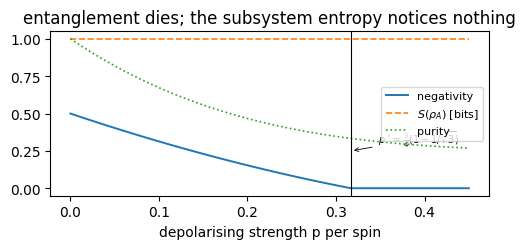

In [17]:
print(f"{'p per spin':>10s} {'purity':>8s} {'S(rho_A)':>9s} {'negativity':>11s}")
pp = np.sort(np.concatenate([np.linspace(0, 0.45, 46), [0.75 * (1 - 1 / np.sqrt(3))]]))
negs, purs = [], []
for p in pp:
    rho = jnp.asarray(rho_bell).reshape(2, 2, 2, 2)
    for q in (0, 1):
        rho = apply_kraus_dm(rho, kraus_depolarizing(float(p)), [q])
    negs.append(neg(rho)); purs.append(float(purity(dm_matrix(rho))))
    if np.isclose(p, [0.0, 0.05, 0.10, 0.20, 0.25, 0.30, 0.75 * (1 - 1 / np.sqrt(3)), 0.35], atol=1e-9).any():
        rA = np.asarray(rdm_dm(rho, (0,)))
        print(f"{p:10.2f} {purs[-1]:8.4f} {S_bits(rA):9.4f} {negs[-1]:11.6f}")

p_death = pp[np.argmax(np.array(negs) <= 1e-12)] if (np.array(negs) <= 1e-12).any() else np.nan
p_star = 0.75 * (1 - 1 / np.sqrt(3))
print(f"\nthe pair becomes separable at about p = {p_death:.3f} per spin from this scan,")
print(f"and the exact threshold is p* = (3/4)(1 - 1/sqrt(3)) = {p_star:.6f}")
print("  it is not a fitted number: depolarising BOTH spins of |Phi+> with strength p each gives exactly the")
print(f"  Werner state with w = (1-4p/3)^2 = {(1-4*p_star/3)**2:.6f}, and Werner is separable for w <= 1/3.")
print("while S(rho_A) never moves from 1 bit: the depolarising channel is unital, so it maps 1/2 to itself, the")
print("input is a Bell pair whose reduced state is already 1/2, and the far channel is trace preserving.")

fig, ax = plt.subplots(figsize=(5, 2.6))
ax.plot(pp, negs, lw=1.4, label="negativity")
ax.plot(pp, [1.0] * len(pp), "--", lw=1.2, label=r"$S(\rho_A)$ [bits]")
ax.plot(pp, purs, ":", lw=1.2, label="purity")
ax.axvline(p_star, color="k", lw=0.8)
ax.annotate(r"$p^*=\frac{3}{4}(1-1/\sqrt{3})$", (p_star, 0.25), fontsize=7,
            xytext=(p_star + 0.03, 0.30), arrowprops=dict(arrowstyle="->", lw=0.6))
ax.set_xlabel("depolarising strength p per spin"); ax.legend(fontsize=8)
ax.set_title("entanglement dies; the subsystem entropy notices nothing")
plt.tight_layout(); plt.show()

## 9. A spin chain: three quantities against distance

Now the question that opened the notebook. Take the ground state of the XXZ chain in a transverse field,

$$ H = \sum_j \big(X_jX_{j+1} + Y_jY_{j+1} + \Delta\, Z_jZ_{j+1}\big) + h_x\sum_j X_j, $$

fix a reference spin near the middle, and follow three quantities as the partner moves away:

* the **negativity** $\mathcal N(r)$ of the pair — their entanglement;
* the **mutual information** $I(i{:}j) = S(\rho_i) + S(\rho_j) - S(\rho_{ij})$ — their total correlation, classical
  and quantum together;
* the **entropy** $S(\rho_{ij})$ of the pair itself.

In [18]:
N = 14
i0 = N // 2 - 1
RS = list(range(1, N // 2 + 1))
PHASES = [("gapless, D=0.5", 0.5, 0.0), ("Heisenberg, D=1", 1.0, 0.0),
          ("Neel, D=1.5", 1.5, 0.0), ("field, hx=1.5", 0.0, 1.5)]
curves = {}
for name, D, h in PHASES:
    _, psi = lanczos_ground_state(heisenberg_terms(N, 1., 1., D, hx=h), N)
    Si = S_bits(rdm(psi, (i0,)))
    nn, ii, ss = [], [], []
    for r in RS:
        j = i0 + r
        rij = rdm(psi, (i0, j))
        Sij = S_bits(rij); Sj = S_bits(rdm(psi, (j,)))
        nn.append(neg(rij)); ii.append(Si + Sj - Sij); ss.append(Sij)
    curves[name] = (nn, ii, ss)
    print(f"{name}:  S(one spin) = {Si:.4f} bit")
    print("   r    " + "".join(f"{r:8d}" for r in RS))
    print("   N(r) " + "".join(f"{v:8.4f}" for v in nn))
    print("   I(r) " + "".join(f"{v:8.4f}" for v in ii))
    print("   S_ij " + "".join(f"{v:8.4f}" for v in ss))

gapless, D=0.5:  S(one spin) = 1.0000 bit
   r           1       2       3       4       5       6       7
   N(r)   0.2755  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000
   I(r)   0.8965  0.1884  0.1537  0.0607  0.0717  0.0243  0.0400
   S_ij   1.1035  1.8116  1.8463  1.9393  1.9283  1.9757  1.9600


Heisenberg, D=1:  S(one spin) = 1.0000 bit
   r           1       2       3       4       5       6       7
   N(r)   0.2924  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000
   I(r)   0.9342  0.1618  0.1315  0.0421  0.0543  0.0146  0.0284
   S_ij   1.0658  1.8382  1.8685  1.9579  1.9457  1.9854  1.9716


Neel, D=1.5:  S(one spin) = 1.0000 bit
   r           1       2       3       4       5       6       7
   N(r)   0.2764  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000
   I(r)   0.9042  0.1900  0.1581  0.0660  0.0783  0.0284  0.0450
   S_ij   1.0958  1.8100  1.8419  1.9340  1.9217  1.9716  1.9550


field, hx=1.5:  S(one spin) = 0.9749 bit
   r           1       2       3       4       5       6       7
   N(r)   0.2064  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000
   I(r)   0.8251  0.2893  0.1869  0.2071  0.1042  0.1226  0.0767
   S_ij   1.1246  1.5769  1.7808  1.7117  1.7501  1.8282  1.4078


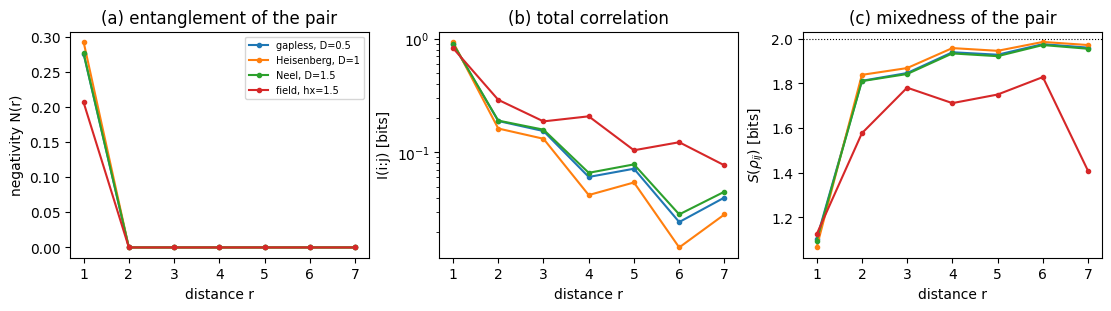

In [19]:
fig, ax = plt.subplots(1, 3, figsize=(11, 3), constrained_layout=True)
for name, _, _ in PHASES:
    nn, ii, ss = curves[name]
    ax[0].plot(RS, nn, "-o", ms=3, label=name)
    ax[1].semilogy(RS, np.maximum(ii, 1e-6), "-o", ms=3)
    ax[2].plot(RS, ss, "-o", ms=3)
ax[0].set_ylabel("negativity N(r)"); ax[0].set_title("(a) entanglement of the pair")
ax[1].set_ylabel("I(i:j) [bits]");   ax[1].set_title("(b) total correlation")
ax[2].set_ylabel(r"$S(\rho_{ij})$ [bits]"); ax[2].set_title("(c) mixedness of the pair")
ax[2].axhline(2.0, ls=":", color="k", lw=0.8)
for a in ax:
    a.set_xlabel("distance r")
ax[0].legend(fontsize=7)
plt.show()

All three panels say something, and none of them says what one might have expected.

**(a) Entanglement between two spins is a nearest-neighbour affair.** The negativity is around $0.2$–$0.3$ at
$r=1$ and *exactly zero* at every larger separation, in every phase. This is not a small number below a tolerance:
the partial transpose is positive, and for two qubits that *proves* the pair is separable.

**(b) Correlation is not entanglement.** The mutual information at $r=2$ and $r=3$ is a sizeable fraction of a bit
and decays slowly, and it distinguishes the phases clearly. All of that correlation is real, and none of it is
entanglement. (Compare the $\langle Z_iZ_j\rangle$ correlators of the entanglement chapter: large and alternating
out to many sites.)

**(c) The pair entropy measures the wrong thing.** $S(\rho_{ij})$ *increases* with $r$, towards $2\,S(\rho_i) = 2$
bits. As the two spins decorrelate, $\rho_{ij}\to\rho_i\otimes\rho_j$ and the entropy becomes the sum of the parts.
A quantity that grows as two spins are pulled apart is not measuring their mutual entanglement — it measures how
entangled the *pair* is with the rest of the chain.

### Monogamy, measured

The three panels have a single explanation. A spin of this chain is maximally mixed, so it is as entangled with the
rest of the register as it can be. Sum its pairwise negativities with *all* other spins and compare.

In [20]:
Nm = 10
_, psi = lanczos_ground_state(heisenberg_terms(Nm, 1., 1., 1., hx=0.0), Nm)
c = Nm // 2 - 1
S_one = S_bits(rdm(psi, (c,)))
pairs = [(j, neg(rdm(psi, (c, j)))) for j in range(Nm) if j != c]
print(f"Heisenberg chain, N={Nm}, reference spin {c}")
print(f"  S(one spin vs the rest)            = {S_one:.6f} bit")
print(f"  sum of its pairwise negativities   = {sum(v for _, v in pairs):.6f}")
print(f"  non-zero pairs: {[(j, round(v,4)) for j, v in pairs if v > 1e-12]}")
print("\nAlmost all of the spin's entanglement is in NO pair at all: it is shared among many spins at once,")
print("and monogamy forbids it from being available bilaterally.  Pairwise entanglement is short-ranged in a")
print("ground state not because the correlations are, but because there is nothing left over.")

Heisenberg chain, N=10, reference spin 4
  S(one spin vs the rest)            = 1.000000 bit
  sum of its pairwise negativities   = 0.386358
  non-zero pairs: [(3, 0.0718), (5, 0.3146)]

Almost all of the spin's entanglement is in NO pair at all: it is shared among many spins at once,
and monogamy forbids it from being available bilaterally.  Pairwise entanglement is short-ranged in a
ground state not because the correlations are, but because there is nothing left over.


## 10. The phase diagram in two measures

Sections 1 to 9 compared the entropy and the negativity on states we chose. The chapter's central figure does it
across a whole phase diagram, the $(\Delta, h_x)$ plane of the XXZ chain in a transverse field, and the point of that
figure is a negative result: the two quantities take their largest values in *different places*, so they are not two
estimates of one thing.

The chapter's maps are $N=16$ on a $31\times31$ grid and $N=32$ by DMRG on a $21\times21$ grid, which together take
hours. The mechanism does not need that resolution, so here we run $N=12$ on an $11\times11$ grid, about a minute,
and check that the qualitative statement already holds. Anyone wanting the chapter's figure changes three numbers.

Two things to watch for, both of which the chapter discusses and neither of which is obvious from a colour map. The
negativity falls to zero on the ferromagnetic side ($\Delta \lesssim -1$, $h_x = 0$) while the entropy there is
almost a full bit: that region is a cat state of two ferromagnets, so the entropy is reporting one *classical* bit of
which-branch information and the negativity is correctly reporting that a mixture of product states holds no
entanglement. And the zero is a numerical zero, not an identity.

In [21]:
Nmap, ng = 12, 11
Ds = np.linspace(-2.0, 2.0, ng)
hs = np.linspace(0.0, 2.0, ng)
cm = Nmap // 2 - 1
S_map = np.zeros((ng, ng)); N_map = np.zeros((ng, ng)); I_map = np.zeros((ng, ng))
t0 = time.perf_counter()
for a, hv in enumerate(hs):
    for b, Dv in enumerate(Ds):
        _, pv = lanczos_ground_state(heisenberg_terms(Nmap, 1., 1., Dv, hx=hv), Nmap)
        S_map[a, b] = float(entanglement_entropy(pv, tuple(range(Nmap // 2))))
        rij = rdm(pv, (cm, cm + 1))
        N_map[a, b] = neg(rij)
        Si = S_bits(rdm(pv, (cm,))); Sj = S_bits(rdm(pv, (cm + 1,)))
        I_map[a, b] = Si + Sj - S_bits(rij)
print(f"{ng}x{ng} grid at N={Nmap} in {time.perf_counter()-t0:.1f} s")

iS = np.unravel_index(S_map.argmax(), S_map.shape)
iN = np.unravel_index(N_map.argmax(), N_map.shape)
print(f"  half-chain entropy: range {S_map.min():.3f} .. {S_map.max():.3f} bits, "
      f"max at (Delta,hx) = ({Ds[iS[1]]:+.2f}, {hs[iS[0]]:.2f})")
print(f"  nn negativity     : range {N_map.min():.3f} .. {N_map.max():.3f},      "
      f"max at (Delta,hx) = ({Ds[iN[1]]:+.2f}, {hs[iN[0]]:.2f})")
print(f"  mutual information: range {I_map.min():.3f} .. {I_map.max():.3f} bits  (never zero anywhere)")
print(f"  the two maxima are at different points: {iS != iN}")

# the ferromagnetic corner, where the entropy and the negativity disagree for a reason
ife = int(np.argmin(np.abs(Ds + 2.0)))
print(f"\nferromagnetic corner (Delta={Ds[ife]:+.2f}, hx=0): S = {S_map[0, ife]:.4f} bits, "
      f"negativity = {N_map[0, ife]:.3e}")
print("  how many of the grid points return EXACTLY 0.0 negativity:",
      int((N_map == 0.0).sum()), "of", N_map.size, "-- the rest are small but non-zero")

11x11 grid at N=12 in 75.6 s
  half-chain entropy: range 0.447 .. 1.372 bits, max at (Delta,hx) = (-0.80, 0.00)
  nn negativity     : range 0.000 .. 0.322,      max at (Delta,hx) = (+0.80, 1.00)
  mutual information: range 0.281 .. 1.066 bits  (never zero anywhere)
  the two maxima are at different points: True

ferromagnetic corner (Delta=-2.00, hx=0): S = 0.8427 bits, negativity = 7.051e-16
  how many of the grid points return EXACTLY 0.0 negativity: 0 of 121 -- the rest are small but non-zero


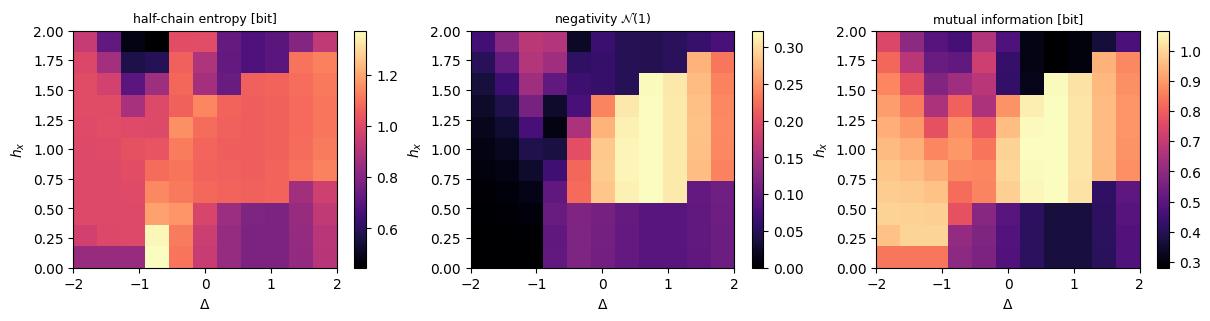

In [22]:
fig, ax = plt.subplots(1, 3, figsize=(12, 3.1), constrained_layout=True)
for a, (M, ttl) in enumerate(((S_map, "half-chain entropy [bit]"),
                              (N_map, r"negativity $\mathcal{N}(1)$"),
                              (I_map, "mutual information [bit]"))):
    im = ax[a].imshow(M, origin="lower", aspect="auto", cmap="magma",
                      extent=[Ds[0], Ds[-1], hs[0], hs[-1]])
    ax[a].set_xlabel(r"$\Delta$"); ax[a].set_ylabel(r"$h_x$"); ax[a].set_title(ttl, fontsize=9)
    fig.colorbar(im, ax=ax[a])
plt.show()

The two maxima land in different places even on this coarse grid, which is the whole claim. The entropy is largest
near the ferromagnetic boundary at zero field; the negativity is largest at positive $\Delta$ *and* finite field,
where the chain is neither ordered nor field-dominated. The mutual information never vanishes, so across a whole
region the central pair is strongly correlated, provably unentangled, and sitting inside a state with a substantial
block entropy.

The chapter also maps the same plane at $N=32$ by DMRG, where no state vector exists, and finds that the entropy's
maximum grows with the chain while the negativity's does not. That is the difference between a quantity attached to a
cut, which has more block to grow into, and a quantity attached to one pair of neighbours, which has nothing to grow
into. Reproducing it needs only `dmrg` in place of `lanczos_ground_state` and `mps_rdm2` in place of `rdm`, both of
which the next sections build and validate.

## 11. The same measures from a matrix product state

Everything so far used an exact state vector, which caps us at about twenty spins. Both quantities can be had from a
matrix product state, and the two divide along a line worth noticing.

**The entropy is free.** An MPS in canonical form *stores* the Schmidt values of every cut, so the entanglement
entropy is a sum over numbers already in the data structure — that is what `mps_entropies` returns. No contraction.

**The negativity is not free**, because it needs the two-site reduced density matrix, and that is a contraction. Let
us derive it rather than quote it. For a right-canonical MPS with Schmidt values `lam`:

1. Everything to the **right** of site $j$ contracts to the identity, by right-canonicity. So it costs nothing.
2. Everything to the **left** of site $i$ contracts to the Schmidt weights $\lambda_i^2$ of that cut.
3. In between, each site is traced over its physical leg — a transfer matrix.

So: open the physical legs at site $i$, walk the transfer matrix to site $j$, and close with the right bond traced.

In [23]:
N, chi, D, h = 12, 32, 1.5, 0.5
B, lam, hist = dmrg(xxz_mpo(N, 1., 1., D, hx=h), product_mps(("01" * N)[:N], chi)[0], chi, 6)
i, j = 4, 7

# step 1: open the physical legs at site i, weighted by the Schmidt values of the cut to its left
T = jnp.einsum("a,asb,atc->stbc", lam[i] ** 2, B[i], jnp.conj(B[i]))
print(f"after site {i}: T has shape {T.shape}   (s,t = physical of site i; b,c = bond ket/bra)")

# step 2: walk through the sites in between, tracing their physical legs
for k in range(i + 1, j):
    T = jnp.einsum("stbc,bud,cue->stde", T, B[k], jnp.conj(B[k]))
    print(f"  through site {k}: shape {T.shape}   (physical leg u is summed -> traced out)")

# step 3: close at site j, keeping its physical legs open and tracing the right bond
R = jnp.einsum("stbc,bud,cvd->sutv", T, B[j], jnp.conj(B[j]))
rho_mps = R.reshape(4, 4)
print(f"\nrho has shape {rho_mps.shape}, trace {float(jnp.trace(rho_mps).real):.12f}")
print("and the engine function does exactly this:")
print("  max|by hand - mps_rdm2| =", np.abs(np.asarray(rho_mps) - np.asarray(mps_rdm2(B, lam, i, j))).max())

after site 4: T has shape (2, 2, 32, 32)   (s,t = physical of site i; b,c = bond ket/bra)
  through site 5: shape (2, 2, 32, 32)   (physical leg u is summed -> traced out)
  through site 6: shape (2, 2, 32, 32)   (physical leg u is summed -> traced out)

rho has shape (4, 4), trace 1.000000000000
and the engine function does exactly this:


  max|by hand - mps_rdm2| = 3.200564813177209e-16


## 12. Agreement of the two implementations

Two pieces of code meant to compute the same thing are worth nothing until they have been made to agree. There is a
size at which the agreement must be *exact*: a matrix product state with $\chi = 2^{N/2}$ discards nothing, so at
that bond dimension DMRG and exact diagonalisation are the same calculation in different coordinates.

In [24]:
print("CHECK 1 -- at chi = 2^(N/2) the MPS is exact, so everything must agree to rounding")
print(f"{'point':>12s} {'N':>2s} {'chi':>4s} | {'|dE|':>9s} {'|dS|':>9s} {'max|d rho_ij| all pairs':>24s}")
for name, D_, h_ in (("gapless", 0.5, 0.0), ("Heisenberg", 1.0, 0.0), ("Neel", 2.0, 0.0),
                     ("Neel+field", 1.5, 0.5), ("field", 0.0, 1.5)):
    for Nv in (4, 6, 8):
        chiv = 2 ** (Nv // 2)
        E, psi_v = lanczos_ground_state(heisenberg_terms(Nv, 1., 1., D_, hx=h_), Nv)
        Bv, lamv, hv = dmrg(xxz_mpo(Nv, 1., 1., D_, hx=h_), product_mps(("01" * Nv)[:Nv], chiv)[0], chiv, 8)
        dS = abs(float(entanglement_entropy(psi_v, tuple(range(Nv // 2))))
                 - float(np.asarray(mps_entropies(lamv))[Nv // 2]))
        drho = max(np.abs(np.asarray(rdm(psi_v, (a, b))) - np.asarray(mps_rdm2(Bv, lamv, a, b))).max()
                   for a in range(Nv - 1) for b in range(a + 1, Nv))
        print(f"{name:>12s} {Nv:2d} {chiv:4d} | {abs(E-hv[-1][3]):9.1e} {dS:9.1e} {drho:24.1e}")

CHECK 1 -- at chi = 2^(N/2) the MPS is exact, so everything must agree to rounding
       point  N  chi |      |dE|      |dS|  max|d rho_ij| all pairs


     gapless  4    4 |   2.7e-15   8.9e-16                  1.2e-15


     gapless  6    8 |   1.1e-14   4.4e-16                  3.3e-14


     gapless  8   16 |   0.0e+00   7.4e-15                  4.8e-15
  Heisenberg  4    4 |   1.8e-15   1.3e-15                  8.3e-16


  Heisenberg  6    8 |   1.2e-14   2.2e-16                  2.2e-15


...

        Neel  8   16 |   3.6e-15   4.0e-15                  8.4e-15
  Neel+field  4    4 |   8.9e-16   1.3e-15                  3.5e-15


  Neel+field  6    8 |   3.6e-15   3.3e-15                  6.8e-14


  Neel+field  8   16 |   2.3e-14   1.5e-14                  6.2e-14
       field  4    4 |   8.9e-16   0.0e+00                  1.8e-15


       field  6    8 |   8.9e-15   1.2e-15                  1.5e-15


       field  8   16 |   2.0e-14   8.9e-16                  5.8e-15


Away from that limit the MPS is an approximation, and *how* it converges is the second check. The useful thing to
watch is whether the negativity converges as fast as the energy, and whether the discarded weight that DMRG already
reports is a usable error bar on it.

In [25]:
print("CHECK 2 -- convergence in chi at N=12, (Delta,hx)=(1.5,0.5)")
E_ex, psi_ex = lanczos_ground_state(heisenberg_terms(12, 1., 1., 1.5, hx=0.5), 12)
S_ex = float(entanglement_entropy(psi_ex, tuple(range(6))))
n_ex = neg(rdm(psi_ex, (5, 6)))
print(f"  exact: E = {E_ex:.12f}   S = {S_ex:.10f} bit   N(1) = {n_ex:.10f}")
print(f"  {'chi':>4s} {'|dE|':>10s} {'|dS|':>10s} {'|dN(1)|':>10s} {'discarded wt':>13s}")
conv = []
for chiv in (2, 4, 8, 16, 32, 64):
    Bv, lamv, hv = dmrg(xxz_mpo(12, 1., 1., 1.5, hx=0.5), product_mps("01" * 6, chiv)[0], chiv, 8)
    eps = max(x[4] for x in hv if x[0] == hv[-1][0])
    dE = abs(E_ex - hv[-1][3])
    dS = abs(S_ex - float(np.asarray(mps_entropies(lamv))[6]))
    dn = abs(n_ex - neg(mps_rdm2(Bv, lamv, 5, 6)))
    conv.append((chiv, dE, dS, dn, eps))
    print(f"  {chiv:4d} {dE:10.2e} {dS:10.2e} {dn:10.2e} {eps:13.2e}")

CHECK 2 -- convergence in chi at N=12, (Delta,hx)=(1.5,0.5)


  exact: E = -24.214627348051   S = 0.8303316868 bit   N(1) = 0.0931604105
   chi       |dE|       |dS|    |dN(1)|  discarded wt


     2   6.17e-01   4.38e-01   9.36e-02      1.26e-02


     4   4.96e-02   8.73e-02   1.52e-02      1.05e-03


     8   3.08e-04   1.01e-03   1.45e-04      7.05e-06


    16   4.69e-07   2.11e-06   2.08e-07      2.72e-08


    32   9.28e-12   1.76e-11   9.70e-12      3.98e-13


    64   4.26e-14   7.17e-14   1.43e-15      4.72e-31


In [26]:
print("CHECK 3 -- is the MPS two-site reduced state even a legitimate density matrix?")
Bv, lamv, hv = dmrg(xxz_mpo(12, 1., 1., 1.5, hx=0.5), product_mps("01" * 6, 64)[0], 64, 8)
wtr = wher = 0.0; weig = 0.0
for a in range(11):
    for b in range(a + 1, 12):
        r = np.asarray(mps_rdm2(Bv, lamv, a, b))
        wtr = max(wtr, abs(np.trace(r).real - 1)); wher = max(wher, np.abs(r - r.conj().T).max())
        weig = min(weig, np.linalg.eigvalsh(r).min())
print(f"  over all 66 pairs: |trace-1| <= {wtr:.1e}, non-hermiticity <= {wher:.1e}, "
      f"most negative eigenvalue {weig:+.1e}")
print("\n  This one matters: a contraction returning a slightly non-positive matrix would hand the partial")
print("  transpose spurious negative eigenvalues and report entanglement where there is none.")

CHECK 3 -- is the MPS two-site reduced state even a legitimate density matrix?


  over all 66 pairs: |trace-1| <= 2.9e-15, non-hermiticity <= 2.3e-16, most negative eigenvalue +0.0e+00

  This one matters: a contraction returning a slightly non-positive matrix would hand the partial
  transpose spurious negative eigenvalues and report entanglement where there is none.


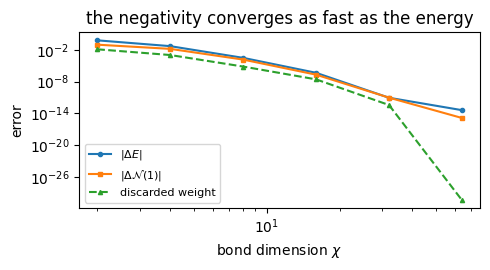

In [27]:
fig, ax = plt.subplots(figsize=(5, 2.8))
cc = [c[0] for c in conv]
ax.loglog(cc, [c[1] for c in conv], "-o", ms=3, label=r"$|\Delta E|$")
ax.loglog(cc, [c[3] for c in conv], "-s", ms=3, label=r"$|\Delta \mathcal{N}(1)|$")
ax.loglog(cc, [c[4] for c in conv], "--^", ms=3, label="discarded weight")
ax.set_xlabel(r"bond dimension $\chi$"); ax.set_ylabel("error")
ax.legend(fontsize=8); ax.set_title("the negativity converges as fast as the energy")
plt.tight_layout(); plt.show()

## 13. The cost of each route

Both methods give the same numbers, so the choice between them is cost. Time one ground state at increasing $N$.
Run this on an otherwise idle machine, or the timings mean nothing. Two further caveats: the DMRG column is six
sweeps throughout, so it scales linearly in a number that is a choice rather than a property of the method; and the
first Lanczos call pays for JIT compilation, which at $N=12$ is most of the measured time (about 1.3 s cold against
0.26 s warm). The cell below therefore runs each solver once to warm it before timing. What survives the caveats is
the shape: one cost grows exponentially in $N$ and the other does not.

In [28]:
print(f"{'N':>3s} | {'Lanczos [s]':>11s} {'DMRG [s]':>9s} | {'|dE|':>9s} {'|dS|':>9s} {'|dN(1)|':>9s}")
cost = []
for Nv in (12, 14, 16, 18, 20):
    cv = Nv // 2 - 1
    lanczos_ground_state(heisenberg_terms(Nv, 1., 1., 1.5, hx=0.5), Nv)          # warm the JIT cache
    t0 = time.perf_counter(); Ev, pv = lanczos_ground_state(heisenberg_terms(Nv, 1., 1., 1.5, hx=0.5), Nv)
    t1 = time.perf_counter()
    t2 = time.perf_counter()
    Bv, lamv, hv = dmrg(xxz_mpo(Nv, 1., 1., 1.5, hx=0.5), product_mps(("01" * Nv)[:Nv], 64)[0], 64, 6)
    t3 = time.perf_counter()
    dS = abs(float(entanglement_entropy(pv, tuple(range(Nv // 2)))) - float(np.asarray(mps_entropies(lamv))[Nv // 2]))
    dn = abs(neg(rdm(pv, (cv, cv + 1))) - neg(mps_rdm2(Bv, lamv, cv, cv + 1)))
    cost.append((Nv, t1 - t0, t3 - t2))
    print(f"{Nv:3d} | {t1-t0:11.1f} {t3-t2:9.1f} | {abs(Ev-hv[-1][3]):9.1e} {dS:9.1e} {dn:9.1e}")

print("\nThe state vector is faster while it fits and its cost doubles with every spin; the MPS cost grows")
print("roughly linearly in N.  On the machine used for the chapter the two cross at about twenty spins,")
print("and past that only the MPS is available at all.")

  N | Lanczos [s]  DMRG [s] |      |dE|      |dS|   |dN(1)|


 12 |         0.4      14.6 |   1.4e-14   7.7e-14   2.0e-15


 14 |         1.3      17.7 |   1.1e-14   3.6e-13   6.7e-16


 16 |         3.2      20.7 |   8.3e-13   1.3e-12   2.2e-14


 18 |        13.8      23.8 |   3.4e-12   8.3e-12   4.0e-13


 20 |        68.7      27.5 |   2.7e-11   4.5e-11   4.2e-13

The state vector is faster while it fits and its cost doubles with every spin; the MPS cost grows
roughly linearly in N.  On the machine used for the chapter the two cross at about twenty spins,
and past that only the MPS is available at all.


## 14. The same plane where no state vector exists

Section 10 mapped the phase diagram with an exact state vector. Now that `dmrg` and `mps_rdm2` have been built and
validated against it, the same map can be made at a chain length no state vector reaches. $N=32$ needs
$2^{32}\approx4\times10^9$ amplitudes as a state vector, which is not a laptop calculation; as a matrix product state
at $\chi=32$ it costs a few seconds per point.

The chapter runs a $21\times21$ grid. Here we run $5\times5$, a few minutes, which is enough for the one qualitative
claim: as the chain grows the entropy maximum grows with it while the negativity maximum does not. That is the
difference between a quantity attached to a cut, which has more block to grow into, and a quantity attached to a
single pair of neighbours, which has nothing to grow into.

In [29]:
Nb, gb, chib = 32, 5, 32
Db = np.linspace(-2.0, 2.0, gb)
hb = np.linspace(0.0, 2.0, gb)
cb = Nb // 2 - 1
S_b = np.zeros((gb, gb)); N_b = np.zeros((gb, gb))
t0 = time.perf_counter()
for a_, hv in enumerate(hb):
    for b_, Dv in enumerate(Db):
        B_, lam_, hist_ = dmrg(xxz_mpo(Nb, 1., 1., Dv, hx=hv),
                               product_mps(("01" * Nb)[:Nb], chib)[0], chib, 4)
        S_b[a_, b_] = float(np.asarray(mps_entropies(lam_))[Nb // 2])
        N_b[a_, b_] = neg(mps_rdm2(B_, lam_, cb, cb + 1))
el = time.perf_counter() - t0
print(f"{gb}x{gb} DMRG grid at N={Nb}, chi={chib} in {el:.0f} s ({el/gb**2:.1f} s per point)")

iS = np.unravel_index(S_b.argmax(), S_b.shape); iN = np.unravel_index(N_b.argmax(), N_b.shape)
print(f"\n  N={Nb}: entropy    range {S_b.min():.3f} .. {S_b.max():.3f} bits, "
      f"max at (Delta,hx) = ({Db[iS[1]]:+.2f}, {hb[iS[0]]:.2f})")
print(f"  N={Nb}: negativity range {N_b.min():.3f} .. {N_b.max():.3f},      "
      f"max at (Delta,hx) = ({Db[iN[1]]:+.2f}, {hb[iN[0]]:.2f})")
print(f"\n  compare Section 10 at N={Nmap}: entropy max {S_map.max():.3f} bits, negativity max {N_map.max():.3f}")
print("  the entropy maximum grew with the chain; the negativity maximum did not.")

ife_b = int(np.argmin(np.abs(Db + 2.0)))
print(f"\nferromagnetic corner (Delta={Db[ife_b]:+.2f}, hx=0):")
print(f"  N={Nb} by DMRG      : S = {S_b[0, ife_b]:.4f} bits, negativity = {N_b[0, ife_b]:.3e}")
print(f"  N={Nmap} by Lanczos : S = {S_map[0, ife]:.4f} bits, negativity = {N_map[0, ife]:.3e}")
print("  Both are right about the state they found. |0...0> and |1...1> are EXACTLY degenerate at every N, so")
print("  Lanczos returns an arbitrary superposition (a cat, whose entropy is one CLASSICAL bit of which-branch")
print("  information) while DMRG settles on one product configuration (entropy zero). The negativity reads zero")
print("  in both, since neither holds pairwise entanglement. A quantity that changes because the solver made an")
print("  arbitrary choice is measuring the choice.")

5x5 DMRG grid at N=32, chi=32 in 405 s (16.2 s per point)

  N=32: entropy    range 0.000 .. 1.974 bits, max at (Delta,hx) = (-1.00, 0.50)
  N=32: negativity range 0.000 .. 0.266,      max at (Delta,hx) = (+1.00, 0.50)

  compare Section 10 at N=12: entropy max 1.372 bits, negativity max 0.322
  the entropy maximum grew with the chain; the negativity maximum did not.

ferromagnetic corner (Delta=-2.00, hx=0):
  N=32 by DMRG      : S = 0.0000 bits, negativity = 7.810e-16
  N=12 by Lanczos : S = 0.8427 bits, negativity = 7.051e-16
  Both are right about the state they found. |0...0> and |1...1> are EXACTLY degenerate at every N, so
  Lanczos returns an arbitrary superposition (a cat, whose entropy is one CLASSICAL bit of which-branch
  information) while DMRG settles on one product configuration (entropy zero). The negativity reads zero
  in both, since neither holds pairwise entanglement. A quantity that changes because the solver made an
  arbitrary choice is measuring the choice.


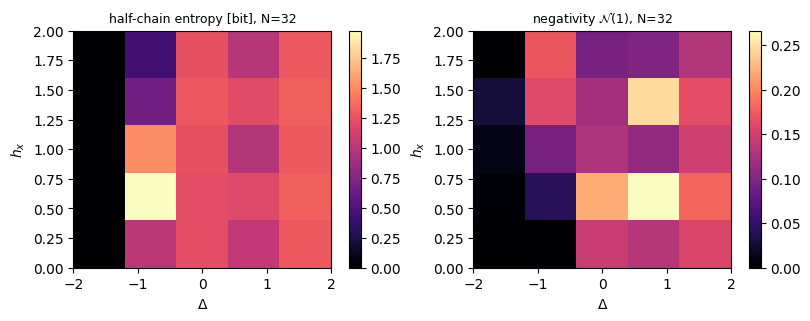

In [30]:
fig, ax = plt.subplots(1, 2, figsize=(8, 3.1), constrained_layout=True)
for a_, (M, ttl) in enumerate(((S_b, f"half-chain entropy [bit], N={Nb}"),
                               (N_b, rf"negativity $\mathcal{{N}}(1)$, N={Nb}"))):
    im = ax[a_].imshow(M, origin="lower", aspect="auto", cmap="magma",
                       extent=[Db[0], Db[-1], hb[0], hb[-1]])
    ax[a_].set_xlabel(r"$\Delta$"); ax[a_].set_ylabel(r"$h_x$"); ax[a_].set_title(ttl, fontsize=9)
    fig.colorbar(im, ax=ax[a_])
plt.show()

# ## 15. Key takeaways
#
# * For a **pure** global state, entanglement across a cut is the Schmidt spectrum. The state is entangled exactly when
#   the reduced state is mixed, and every measure is a function of the $p_k$ -- every Schur-concave function of them is
#   an LOCC monotone, so the entropy is canonical rather than unique. The log-negativity of such a cut is the
#   Rényi-$\tfrac12$ entropy, which is the second such monotone and carries nothing new.
# * A single number at a single cut is **not** a classification. GHZ and the Dicke state are indistinguishable by one
#   spin, yet GHZ has exactly zero pairwise entanglement, provably so from its two-spin state. GHZ and W are
#   inequivalent classes.
# * For a **mixed** state the subsystem entropy is not an entanglement measure: a Bell pair and a classical coin toss
#   have the same reduced state and the same one bit of entropy, and negativity $0.5$ against $0$.
# * Quantifying mixed-state entanglement properly means minimising over ensembles, which has no closed form beyond two
#   qubits. The computable substitute is the **PPT criterion**, and the negativity is how negative the partial
#   transpose is. It reproduces the Werner threshold $p=\tfrac13$ exactly rather than approximately, since the smallest
#   partial-transpose eigenvalue there is $(1-3p)/4$; under two-sided depolarising noise the same threshold appears as
#   $p^* = \tfrac34(1-1/\sqrt3) = 0.316987$ per spin.
# * In a chain ground state, pairwise entanglement is nearest-neighbour in every phase, and provably so, since a more
#   distant pair has a positive partial transpose and two spins lie inside the range where PPT decides. The mutual
#   information is long-ranged and phase-dependent, and the pair entropy grows with separation towards
#   $2S(\hat\rho_i)$. Correlation is not entanglement, and monogamy is the reason. Note that on an open chain the
#   nearest-neighbour negativity alternates strongly from bond to bond, so "the central pair" is a specific strong bond.
# * Both measures come from a state vector or from an MPS. The entropy is free from the Schmidt values; the negativity
#   needs a two-site reduced state, a three-step contraction costing $O(j\chi^3)$ when built from the left boundary.
#   The two agree to $10^{-11}$ and the cost crosses over around twenty spins on the machine used here.
#
# ## 16. Exercises
#
# 1. (★) Write the two-spin reduced state of GHZ at $N=5$ and confirm it is $\tfrac12\mathrm{diag}(1,0,0,1)$. Check that
#    its partial transpose has no negative eigenvalue, and explain why the two facts had to agree.
# 2. (★) Find the PPT boundary of the Werner state by bisection instead of by scanning, and compare with $1/3$. Then
#    replace $\mathbb 1/4$ by $\vert00\rangle\langle00\vert$ and find the new threshold.
# 3. (★) Verify the pure-state identity $E_{\mathcal N} = 2\log_2\sum_k\lambda_k$ on a Haar-random state of eight spins
#    for *every* contiguous cut, and plot it against $S(\ell)$.
# 4. (★★) For the Heisenberg ground state at $N=10$, compute the negativity of every pair containing a fixed spin and
#    compare the sum with that spin's entropy against the rest. Repeat at $\Delta=0$ and $\Delta=2$: does the deficit
#    grow or shrink with the anisotropy?
# 5. (★★) Generalise the contraction of Section 10 to two **blocks** of $L$ adjacent sites. Show that $L=1$ reproduces
#    Section 9(a) and that $L=3$ does *not* vanish beyond $r=1$. Why does block size help?
# 6. (★★) Repeat Section 8 with the dephasing channel instead of the depolarising one. At what strength does the pair
#    become separable, and why does the answer differ?
# 7. (★★★) Reproduce Section 12 on your own machine and locate the crossover. Then repeat the DMRG column at
#    $\chi=32$ and $\chi=128$ and explain which parts of the curve move and which do not.
#
# ## 17. References
#
# * A. Peres, *Separability Criterion for Density Matrices*, Phys. Rev. Lett. **77**, 1413 (1996).
# * M. Horodecki, P. Horodecki, R. Horodecki, *Separability of mixed states: necessary and sufficient conditions*,
#   Phys. Lett. A **223**, 1 (1996).
# * G. Vidal, R. F. Werner, *Computable measure of entanglement*, Phys. Rev. A **65**, 032314 (2002).
# * M. B. Plenio, *Logarithmic Negativity: A Full Entanglement Monotone That is not Convex*, Phys. Rev. Lett. **95**,
#   090503 (2005).
# * W. K. Wootters, *Entanglement of Formation of an Arbitrary State of Two Qubits*, Phys. Rev. Lett. **80**, 2245 (1998).
# * V. Coffman, J. Kundu, W. K. Wootters, *Distributed entanglement*, Phys. Rev. A **61**, 052306 (2000).
# * L. Amico, R. Fazio, A. Osterloh, V. Vedral, *Entanglement in many-body systems*, Rev. Mod. Phys. **80**, 517 (2008).

---
**About these lectures.** Written by Marcin Płodzień (Institute of Theoretical Physics, Jagiellonian University; [ORCID](https://orcid.org/0000-0002-0835-1644), [GitHub](https://github.com/MarcinPlodzien)) as self-study material for the course *Quantum Many-Body Simulation: from a single spin to quantum machine learning*. The notebook is self-contained: the *Engine recap* cell holds every function of the SmoQ.jax engine it uses. If you use this material in teaching or research, please credit the author:

> M. Płodzień, *Quantum Many-Body Simulation: from a single spin to quantum machine learning*, hands-on lectures in JAX with the SmoQ.jax engine (2026), https://marcinplodzien.github.io/quantum-many-body-simulation/